In [1]:
import scipy as sp
from copy import deepcopy 
from tqdm import tqdm
import os
import sys
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'  # For sharper figures, but it takes more time
import matplotlib.cm as cm
import multiprocessing as mp
import scipy as sp
import time
from datetime import datetime

# LISA modules
from lisatools.utils.constants import *
from lisatools.sensitivity  import AE1SensitivityMatrix, AET1SensitivityMatrix, LISASens
from bbhx.waveformbuild import BBHWaveformFD
from bbhx.waveforms.phenomhm import PhenomHMAmpPhase

# Immports for generating simulated LISA data
import noise_generation as noise_generation
from tools.LISASimulator import LISASimulator
from tools.likelihood import get_dh, get_hh
import tools.likelihood as likelihood

# Imports for MCMC
from tools.save_and_load_DE import load_de_results
from tools.time_freq_likelihood import TimeFreqLikelihood
from eryn.ensemble import EnsembleSampler
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.state import State
from scipy.stats import truncnorm
from copy import deepcopy
# Imports for plotting
from chainconsumer import Chain, ChainConsumer, make_sample, Truth
import pandas as pd
import corner
import pickle

param_labels = [
    r"$M_T \, [\mathrm{M_\odot}]$",
    r"$q$",
    r"$a_1$",
    r"$a_2$",
    r"$d_L \, [\mathrm{Gpc}]$",
    r"$\phi_{\mathrm{ref}}$",
    r"$\cos(\iota)$",
    r"$\lambda$",
    r"$\sin(\beta)$",
    r"$\psi$",
    r"$t_{\mathrm{c}} \, [\mathrm{s}]$"
]
from tools.MBHB_differential_evolution import MBHB_finder_time_frequency, MBHB_finder_lisatools, MBHB_finder_frequency_domain, transform_bbhx_to_parameters, transform_parameters_to_bbhx
from lisatools.sensitivity import get_sensitivity
from bbhx.waveforms.phenomhm import PhenomHMAmpPhase

from matplotlib import rc
rc('font', **{
'family': 'serif',
'serif': ['Computer Modern Roman'],
 'size' : 16
})
rc('text', usetex=True)
import matplotlib.pyplot as plt

No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU interpolation available.
No CuPy or GPU response available.


In [2]:
1.2*YRSID_SI/12/(3600*24)

36.5256363004

In [3]:
Tobs = 1.2*YRSID_SI/12
dt = 5.
include_T_channel = False

wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), use_gpu=False,)
sim = LISASimulator(Tobs=Tobs, dt=dt, wave_gen=wave_gen, include_T_channel=include_T_channel)

m1 = 3e5
m2 = 1.5e5
a1 = 0.753
a2 = 0.621
dist = 10 * PC_SI * 1e9
phi_ref = 0.0 #np.pi/2
f_ref = 0.0
inc = 0.224
lam = 60*(np.pi/180)
beta = 20*(np.pi/180)
psi = 0
t_ref = Tobs - (24*60*60)

m1 = 2e5
m2 = 0.5e5
a1 = 0
a2 = 0
dist = 5 * PC_SI * 1e9 #dist = 27.7 * PC_SI * 1e9
phi_ref = 2.66
f_ref = 0.0
inc = 0.924
lam = 3.45
beta= 0.44
psi = 3.42
t_ref = Tobs - (24*60*60)

parameters = np.array([m1, m2, a1, a2, dist, phi_ref, f_ref, inc, lam, beta, psi, t_ref])
modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]
waveform_kwargs = dict(length=1024, direct=False, fill=True, squeeze=False, modes=modes)
data_t, data_f, f_array, t_array, sens_mat = sim(seed = 42, parameters=parameters, waveform_kwargs=waveform_kwargs)
waveform_kwargs.update(freqs=f_array)
print(f"SNR of the Signal: {sim.SNR_optimal()[0]}")

SNR of the Signal: 1832.1159393004868


In [4]:
np.pi

3.141592653589793

In [5]:
hours_before_merger = 10
time_before_merger = hours_before_merger*60*60
cutoff_time = t_ref - time_before_merger
width_of_tref_prior = 20
max_time = t_ref + (width_of_tref_prior - hours_before_merger)*60*60
nperseg = 1414

In [6]:
30*np.pi/180

0.5235987755982988

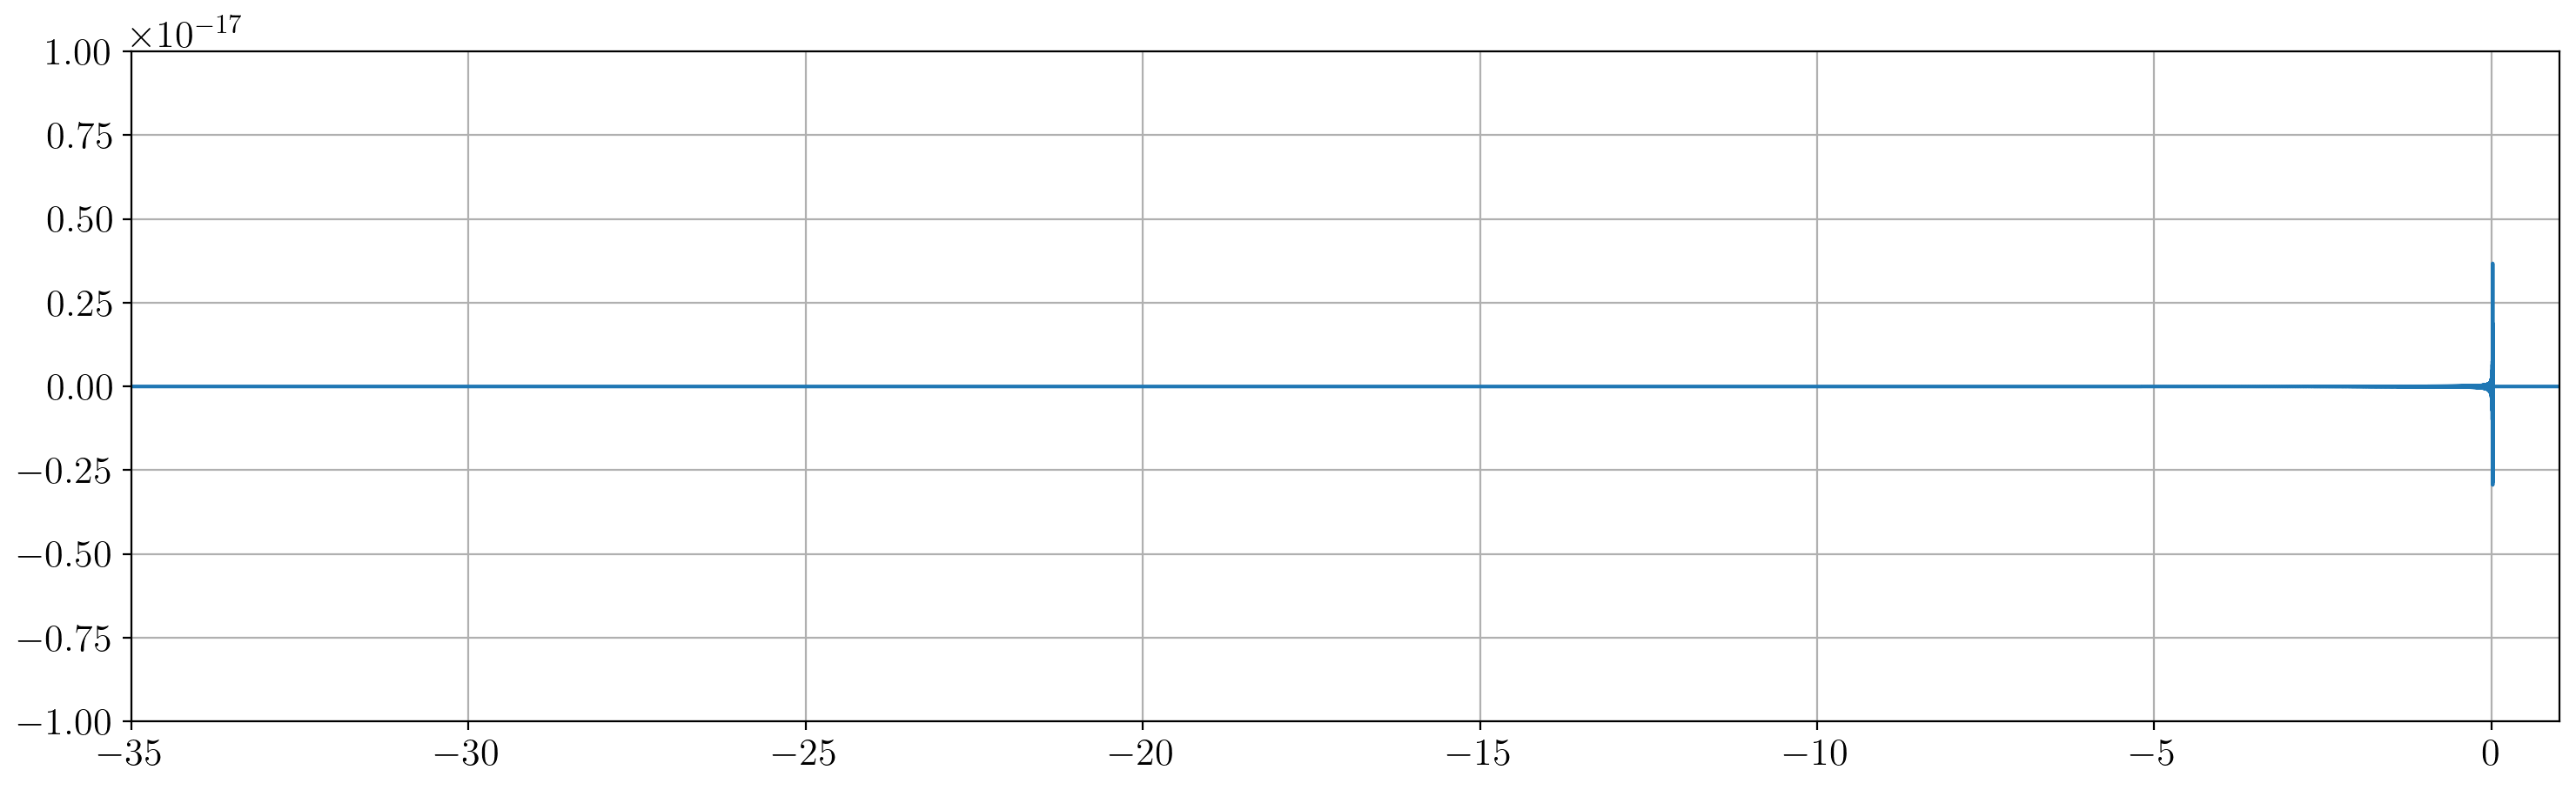

In [7]:
## Construct a time array for plotting that has t_ref/dt at zero seconds converted to hours
time = sim.time
time = ((time - t_ref) / 3600 + 0.25)/24  # in days

wave_plotted = sim.signal_t[0][1]


plt.figure(figsize=(18, 5))
plt.plot(time, wave_plotted)
plt.xlim(-35, time[-1])
plt.ylim(-1e-17, 1e-17)
plt.grid('on')

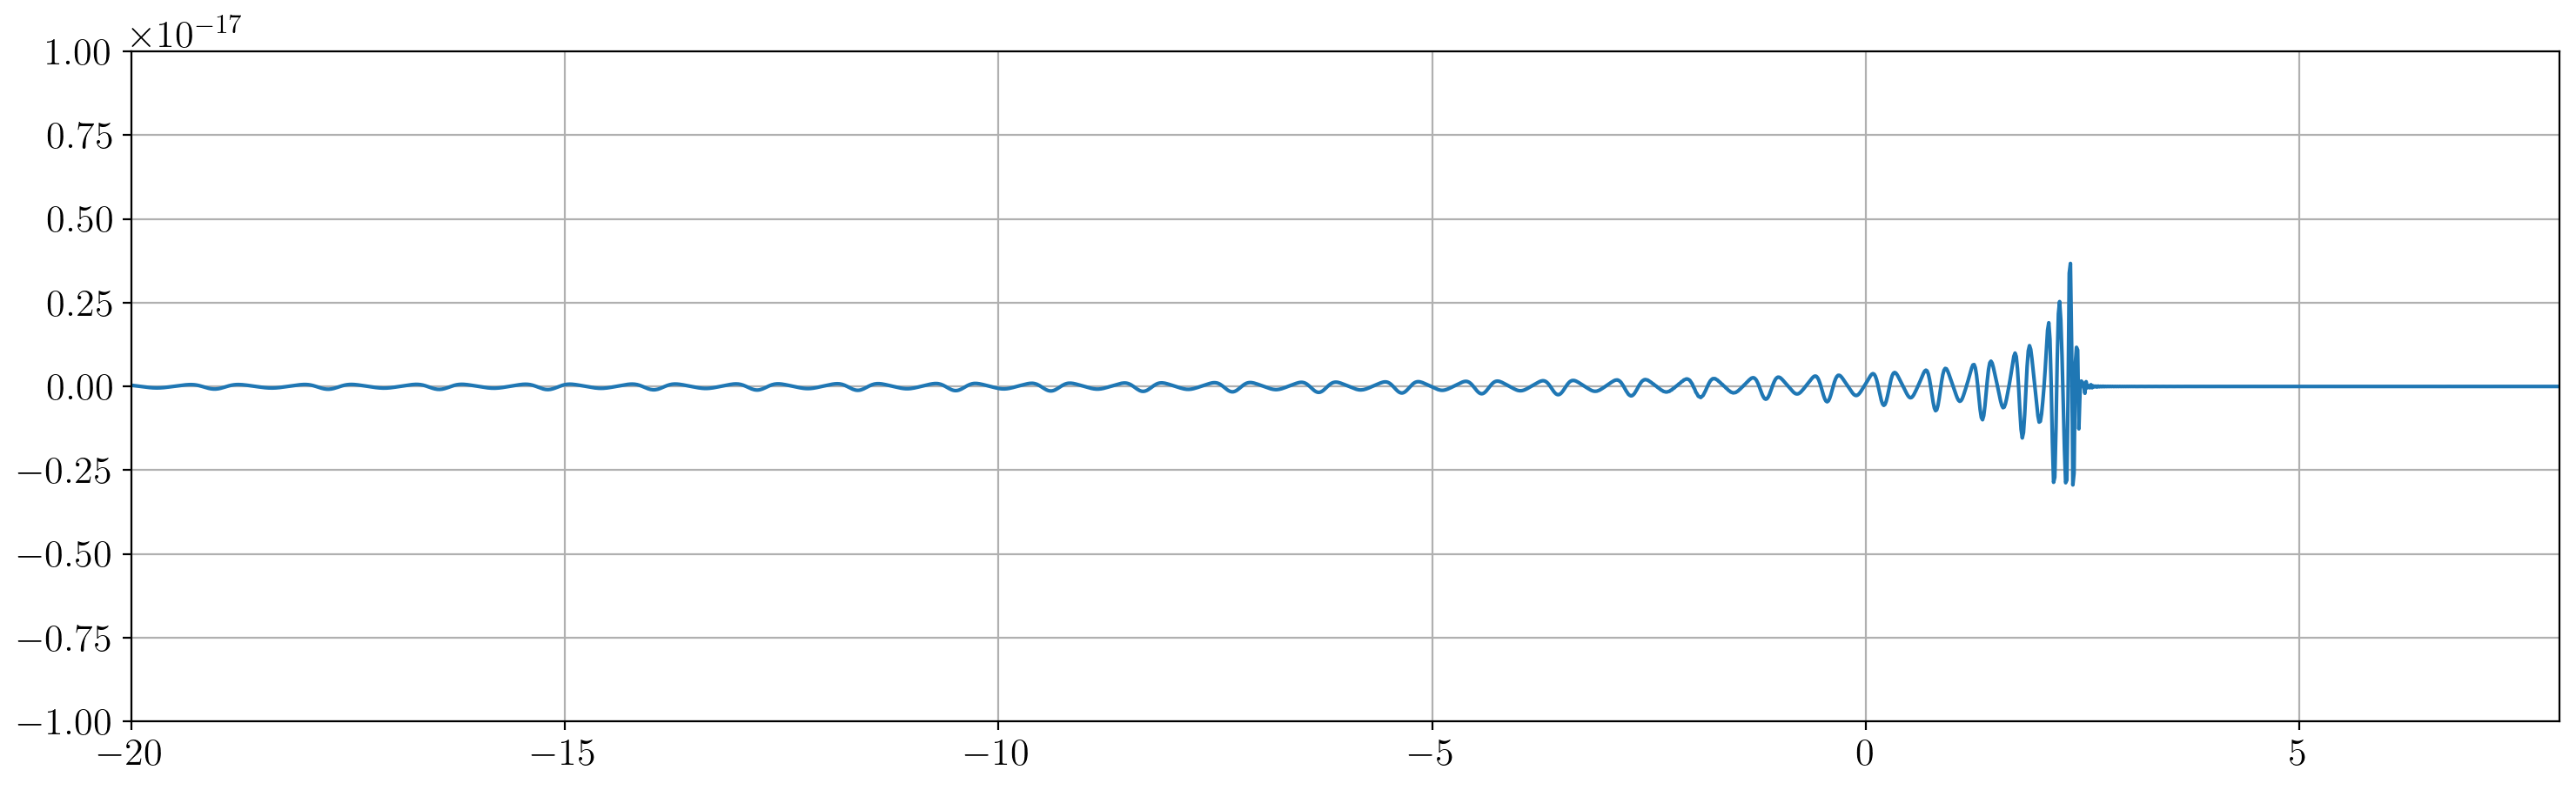

In [8]:
## Construct a time array for plotting that has t_ref/dt at zero seconds converted to hours
time = sim.time
time = time - t_ref
time = time / 360  # Convert seconds to hours

plt.figure(figsize=(18, 5))
plt.plot(time, sim.signal_t[0][1])
#plt.plot(time, sim.noise_t[1], color='gray')
plt.xlim(-20, 8)

#plt.xlim(-1000, -500)
plt.ylim(-1e-17, 1e-17)
plt.grid('on')

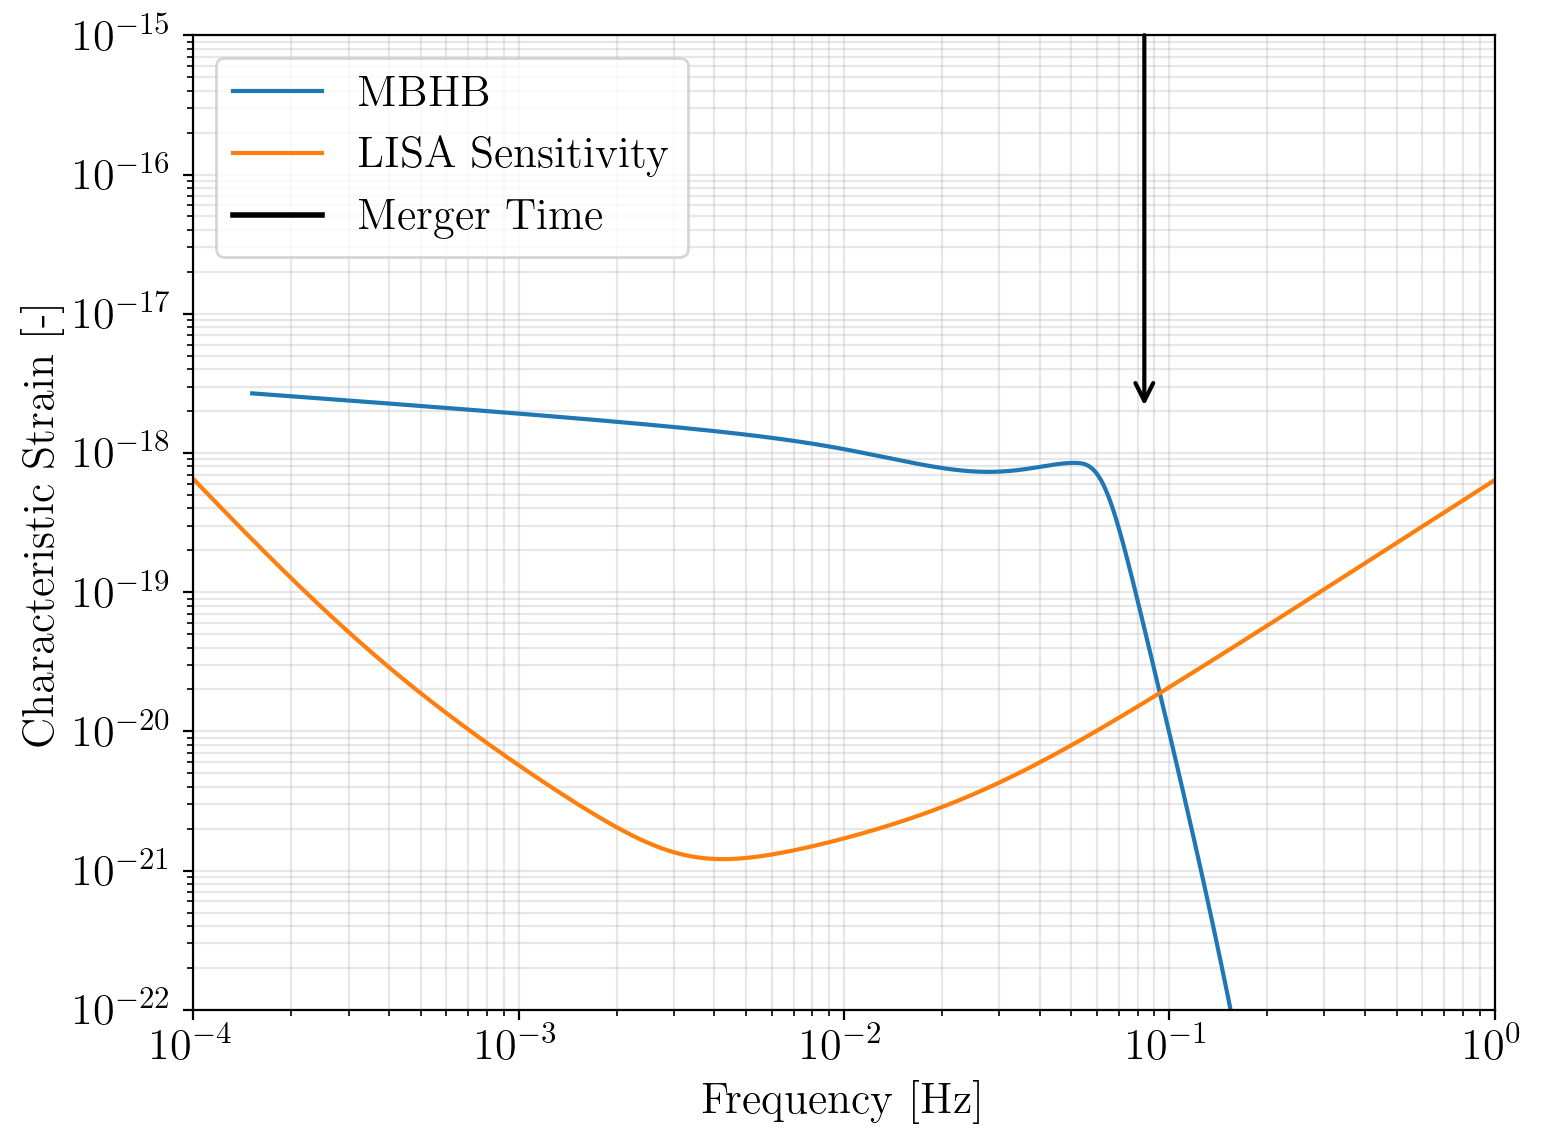

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

t_ref_frequency = 2*YRSID_SI - (24*60*60)
wave_gen_frequency = PhenomHMAmpPhase()
wave_gen_frequency(m1, m2, a1, a2, dist, phi_ref, f_ref, t_ref_frequency, length=1024)

fn = np.logspace(-4, 1, 10000)
Sn_char_strain = get_sensitivity(fn, sens_fn="LISASens", return_type="char_strain") 

modes = [(2,2)]

plt.figure(figsize=(8, 6))
for i, mode in enumerate(modes):
    char_strain = wave_gen_frequency.freqs_shaped[0, i] * wave_gen_frequency.amp[0, i]
    plt.loglog(wave_gen_frequency.freqs_shaped[0, i], char_strain, label='MBHB')

index_of_coalescence = 800

# Draw the arrow showing merger
plt.annotate('', 
    xy=(wave_gen_frequency.freqs_shaped[0, 0][index_of_coalescence], 2e-18),
    xytext=(wave_gen_frequency.freqs_shaped[0, 0][index_of_coalescence], 1.1e-15),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5)
)

# Add the LISA sensitivity curve
plt.loglog(fn, Sn_char_strain, label="LISA Sensitivity")

""
# Create a thin custom legend arrow
import matplotlib.lines as mlines

arrow_handle = mlines.Line2D(
    [0], [0],
    color='black',
    lw=2.0,
   
    markersize=10,
    label='Merger'
)

# Combine normal legend entries with the arrow handle
handles, labels = plt.gca().get_legend_handles_labels()
handles.append(arrow_handle)
labels.append("Merger Time")
""
plt.legend(handles, labels)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Characteristic Strain [-]")
plt.ylim(1e-22, 1e-15)
plt.xlim(1e-4, 1e0)
plt.grid(which="both", alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:
sim.noise_t[0]


array([-1.05259573e-20,  1.11637247e-20, -2.28453873e-20, ...,
       -2.41769855e-21,  2.25397199e-21, -1.76442279e-20], shape=(631162,))

In [11]:
# Tobs is the obvesrvation time in seconds. YRSID_SI is a siderial year = 31558149.763545603 seconds
Tobs = YRSID_SI / 2.

# This is the sampling interval, i.e., the time between two samples. The sampling rate is 1/dt
dt = 5.  # sec

# N is the number of samples in your original time-domain signal.
N = int(int(Tobs / dt)/2)*2

# Convert Tobs into an integer number.
Tobs = N * dt

# This function returns the array of sample frequencies corresponding to the positive frequencies of the real-input Fast Fourier Transform (rFFT)
# The list goes from from zero to the Nyquist frequency, which is half the sampling rate: f[-1] = df/2 = 1/(2*dt)
# len(f) = floor(N/2) + 1 because the Nyquist frequency is included and the negative frequencies are not included in the rFFT
freq = np.fft.rfftfreq(N,dt)

# f[0] is 0.0. To avoid this, set f[0] to f[1]
freq[0] = freq[1]



wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), use_gpu=False)

m1 = 8e5 # 1e5
m2 = 2e5 # 1e5
# chi1z and chi2z are the dimensionless spins of the two black holes assumed to be aligned with the orbital angular momentum.
chi1z = 0.5
chi2z = 0.7
dist = 200 * 1e9 * PC_SI # lower distance try this 
phi_ref = 0.0
f_ref = 0.0
inc = np.pi/3.
beta = np.pi/2. # ecliptic latitude
lam = np.pi  # ecliptic longitude
psi = np.pi/6.  # polarization angle
t_ref = Tobs/2  #- 60*60*24  # t_ref  (in the SSB reference frame) = merger time.

modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

wave_freq_domain = wave_gen(m1, m2, chi1z, chi2z,
                            dist, phi_ref, f_ref, inc, lam,
                            beta, psi, t_ref, 
                            freqs=freq, modes=modes, 
                            direct=False, fill=True, squeeze=True, length=1024)[0]


In [12]:
# Tobs is the obvesrvation time in seconds. YRSID_SI is a siderial year = 31558149.763545603 seconds
Tobs = YRSID_SI / 2.

# This is the sampling interval, i.e., the time between two samples. The sampling rate is 1/dt
dt = 5.  # sec

# N is the number of samples in your original time-domain signal.
N = int(int(Tobs / dt)/2)*2

# Convert Tobs into an integer number.
Tobs = N * dt

# This function returns the array of sample frequencies corresponding to the positive frequencies of the real-input Fast Fourier Transform (rFFT)
# The list goes from from zero to the Nyquist frequency, which is half the sampling rate: f[-1] = df/2 = 1/(2*dt)
# len(f) = floor(N/2) + 1 because the Nyquist frequency is included and the negative frequencies are not included in the rFFT
freq = np.fft.rfftfreq(N,dt)

# f[0] is 0.0. To avoid this, set f[0] to f[1]
freq[0] = freq[1]

# stochastic_params in sens_kwargs takes the time to add galactic foreground noise. It makes sense to put it as Tobs, which is the duration of observation.
# This is why N was calculated using Tobs and not written explicitly.
sens_kwargs = dict(stochastic_params=(Tobs,))

# Put the LISA sensitivity model in a list. See lisatools.sensitivity.get_stock_sensitivity_options for the list of available models.
# Does not work for FlatPSDFunction and it's slightly higher than the model for LISASens and CornishLISASens at low frequencies.
plot_labels = ['A', 'E', 'T']

# SensitivityMatrix class gives a model of the LISA instrumental noises, given a frequency array, for every TDI channel in sens_model_array
sens_mat = AET1SensitivityMatrix(freq)

noises = noise_generation.generate_noise(N, dt, sens_mat, seed = 42, verification_plot=False, time_domain_plot=False, plot_lables=plot_labels)

fout, pxxout = noise_generation.noise_time_to_freq_domain(noises, dt)

wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), use_gpu=False)

m1 = 8e5 # 1e5
m2 = 2e5 # 1e5
# chi1z and chi2z are the dimensionless spins of the two black holes assumed to be aligned with the orbital angular momentum.
chi1z = 0.5
chi2z = 0.7
dist = 200 * 1e9 * PC_SI # lower distance try this 
phi_ref = 0.0
f_ref = 0.0
inc = np.pi/3.
beta = np.pi/2. # ecliptic latitude
lam = np.pi  # ecliptic longitude
psi = np.pi/6.  # polarization angle
t_ref = Tobs/2  #- 60*60*24  # t_ref  (in the SSB reference frame) = merger time.

modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

wave_freq_domain = wave_gen(m1, m2, chi1z, chi2z,
                            dist, phi_ref, f_ref, inc, lam,
                            beta, psi, t_ref, 
                            freqs=freq, modes=modes, 
                            direct=False, fill=True, squeeze=True, length=1024)[0]

wave_time_domain = np.fft.irfft(wave_freq_domain, axis=-1)
wave_time_domain_with_noise = wave_time_domain + noises
fout_withnoise, pxxout_withnoise = noise_generation.noise_time_to_freq_domain(wave_time_domain_with_noise, dt, winow_length_denominotor=4.5)

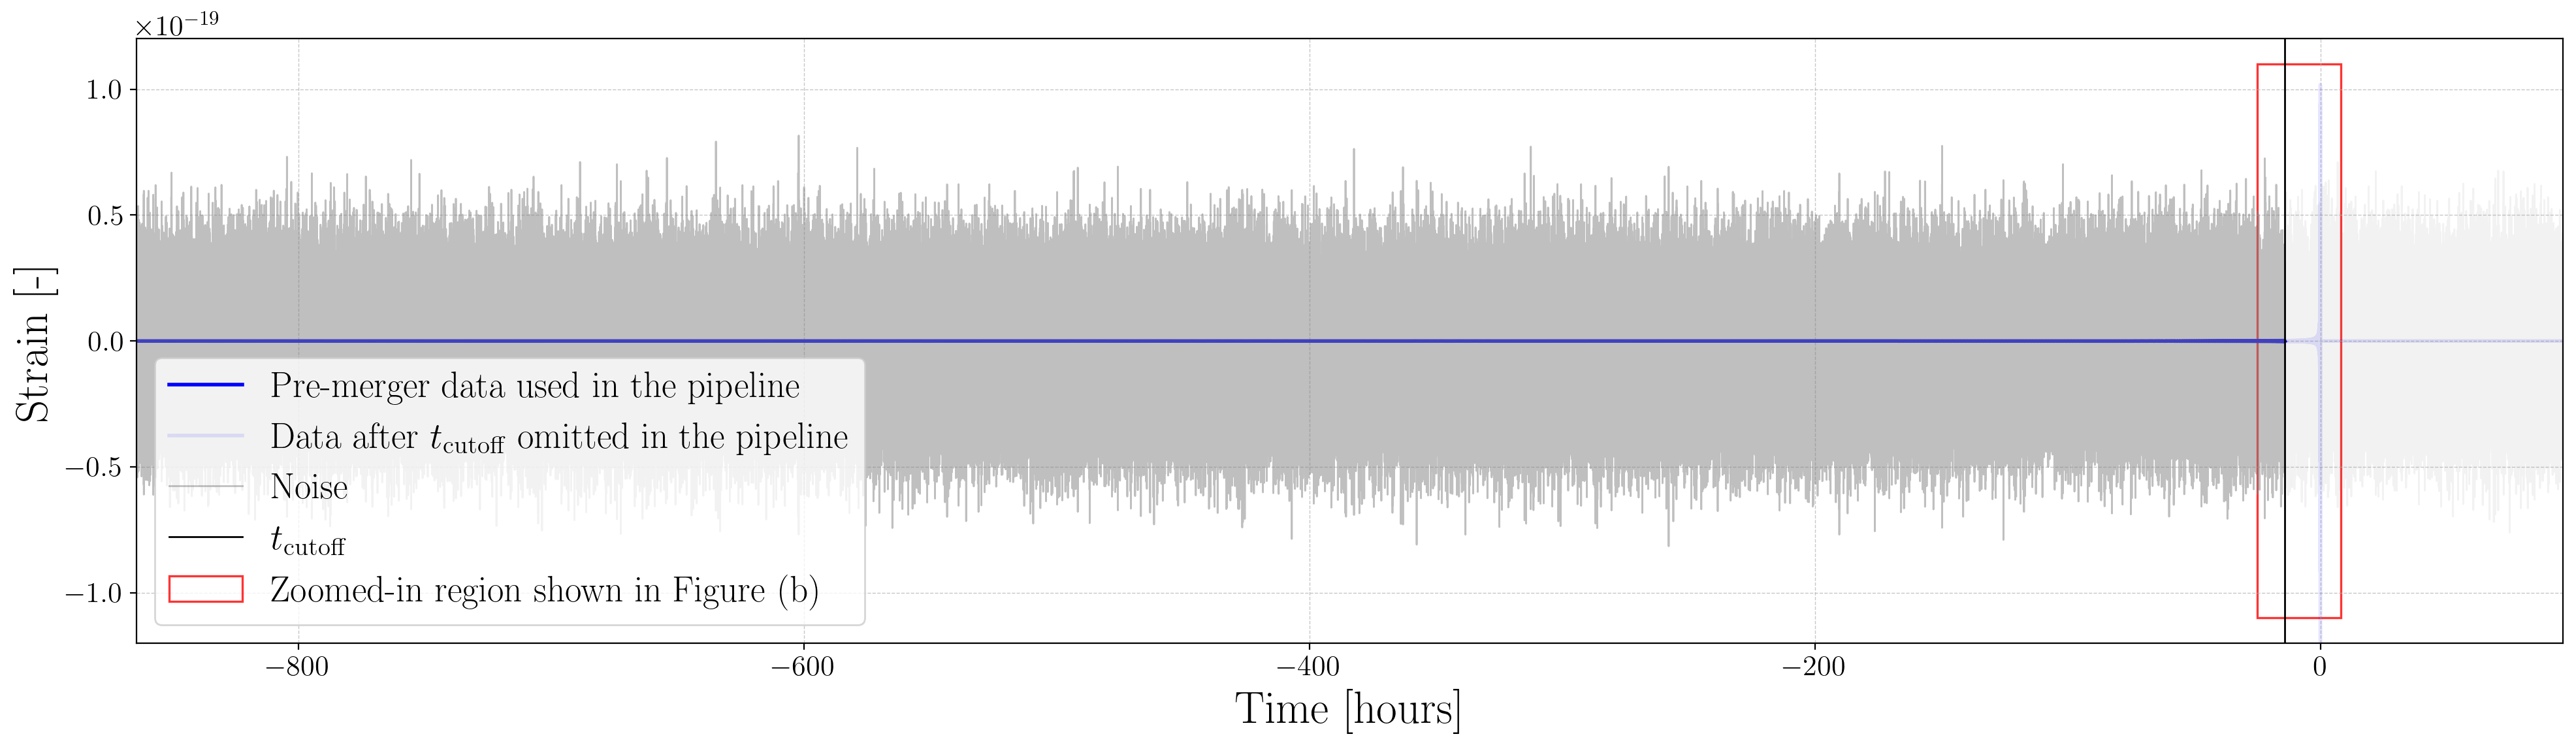

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(20, 6))
time = np.arange(len(wave_time_domain[0])) * dt - t_ref  # Shift time so that t_ref is at 0 seconds
seconds_per_month = 1 * 3600  # 30 days in seconds
time_hours = time / 3600
time_days = time_hours 

# Split index where time = -14 days
split_idx = np.where(time_days >= -14)[0][0]

# Left side (normal opacity)

plt.plot(time_days[:split_idx], wave_time_domain[0][:split_idx],
         color='blue', lw=2, label='Pre-merger data used in the pipeline')

# Right side (less opacity)
plt.plot(time_days[split_idx:], noises[1][split_idx:],
         color='gray', alpha=0.1, lw=1)
plt.plot(time_days[split_idx:], wave_time_domain[1][split_idx:],
         color='blue', alpha=0.1, lw=2, label=r'Data after $t_{\rm cutoff}$ omitted in the pipeline')

plt.plot(time_days[:split_idx], noises[1][:split_idx],
         color='gray', alpha=0.5, lw=1, label='Noise')

# Coalescence marker
#plt.axvline(0, color='k', ls='--', lw=1, label=r'$t_c$')
plt.axvline(-14, color='k', lw=1, label=r'$t_{\rm cutoff}$')

# Add rectangular box
from matplotlib.patches import Rectangle
rect = Rectangle(
    (-25, -1.1e-19),      # (x, y) lower-left corner
    8 - (-25),            # width = x2 - x1
    1.1e-19 - (-1.1e-19), # height = y2 - y1
    linewidth=1.2,
    edgecolor='red',
    facecolor='none',
    alpha=0.8,
    label = 'Zoomed-in region shown in Figure (b)'
)
plt.gca().add_patch(rect)


# Labels & limits
plt.xlabel('Time [hours]', fontsize=25)
plt.ylabel('Strain [-]', fontsize=25)

plt.xlim(-36*24, 4*24)
plt.ylim(-1.2e-19, 1.2e-19)
# Grid & legend
plt.grid(True, ls='--', lw=0.5, alpha=0.7)
plt.legend(loc='lower left', fontsize=20, frameon=True)
plt.tight_layout()



# Save figure as pdf
plt.savefig('waveform_time_domain_big.pdf', dpi=300)
plt.show()


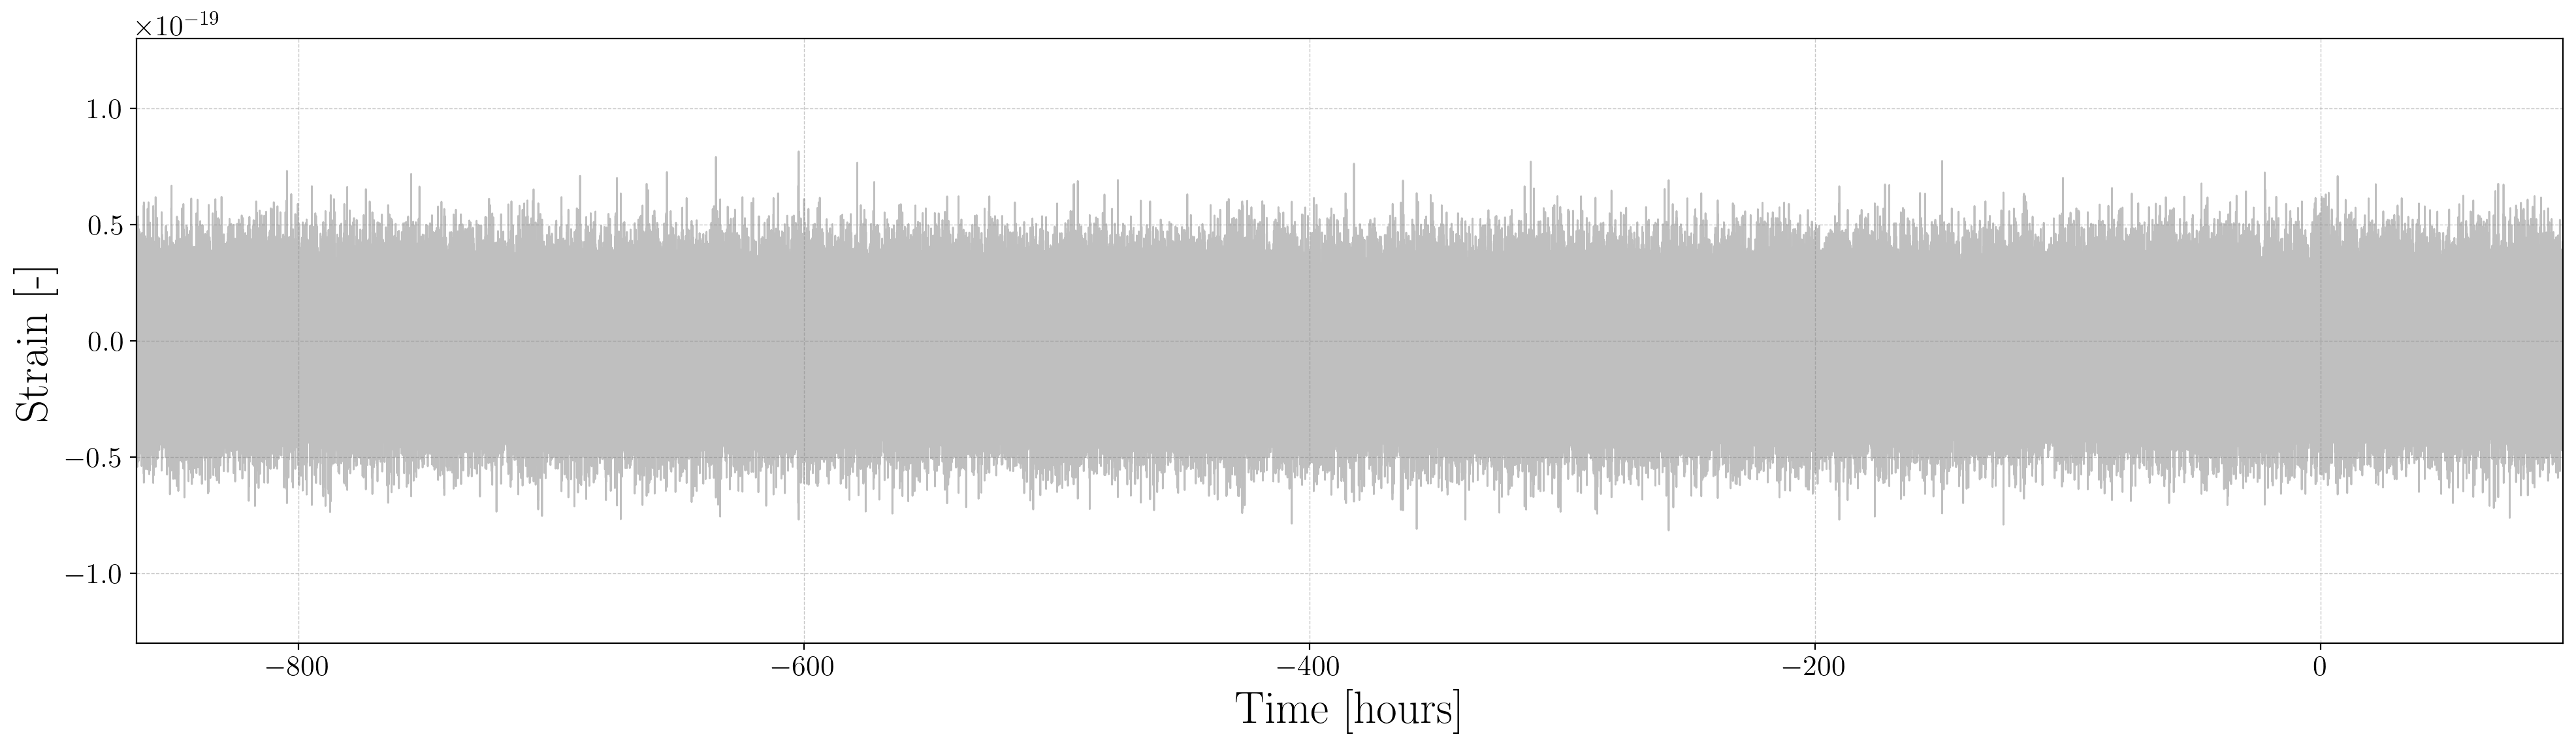

In [14]:
plt.figure(figsize=(20, 6))
time = np.arange(len(wave_time_domain[0])) * dt - t_ref  # Shift time so that t_ref is at 0 seconds
seconds_per_month = 1 * 3600  # 30 days in seconds
time_hours = time / 3600
time_days = time_hours 

plt.plot(time_days, noises[1], color='gray', alpha=0.5, lw=1)
#plt.plot(time_days, wave_time_domain[1], color='blue', lw=2)
plt.xlim(-36*24, 4*24)
plt.ylim(-1.3e-19, 1.3e-19)
plt.xlabel('Time [hours]', fontsize=25)
plt.ylabel('Strain [-]', fontsize=25)
plt.grid(True, ls='--', lw=0.5, alpha=0.7)
plt.tight_layout()

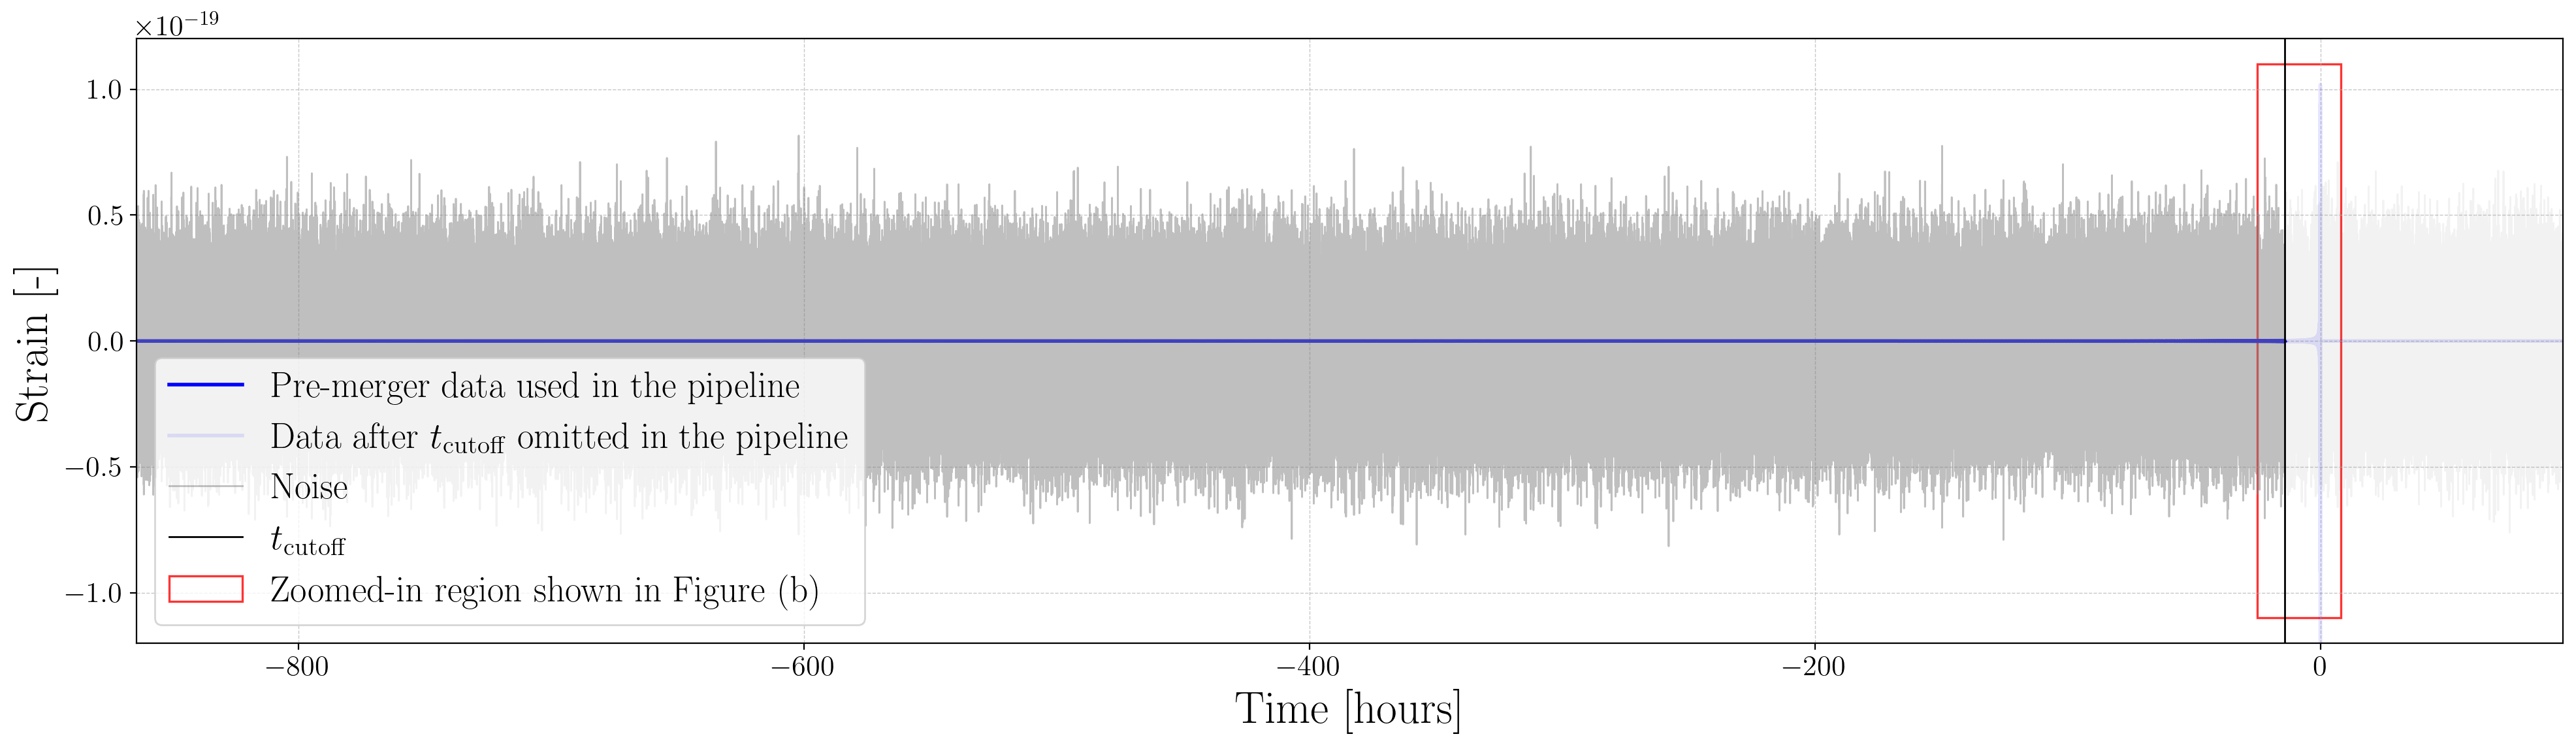

In [15]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(20, 6))
time = np.arange(len(wave_time_domain[0])) * dt - t_ref  # Shift time so that t_ref is at 0 seconds
seconds_per_month = 1 * 3600  # 30 days in seconds
time_hours = time / 3600
time_days = time_hours 

# Split index where time = -14 days
split_idx = np.where(time_days >= -14)[0][0]

# Left side (normal opacity)

plt.plot(time_days[:split_idx], wave_time_domain[0][:split_idx],
         color='blue', lw=2, label='Pre-merger data used in the pipeline')

# Right side (less opacity)
plt.plot(time_days[split_idx:], noises[1][split_idx:],
         color='gray', alpha=0.1, lw=1)
plt.plot(time_days[split_idx:], wave_time_domain[1][split_idx:],
         color='blue', alpha=0.1, lw=2, label=r'Data after $t_{\rm cutoff}$ omitted in the pipeline')

plt.plot(time_days[:split_idx], noises[1][:split_idx],
         color='gray', alpha=0.5, lw=1, label='Noise')

# Coalescence marker
#plt.axvline(0, color='k', ls='--', lw=1, label=r'$t_c$')
plt.axvline(-14, color='k', lw=1, label=r'$t_{\rm cutoff}$')

# Add rectangular box
from matplotlib.patches import Rectangle
rect = Rectangle(
    (-25, -1.1e-19),      # (x, y) lower-left corner
    8 - (-25),            # width = x2 - x1
    1.1e-19 - (-1.1e-19), # height = y2 - y1
    linewidth=1.2,
    edgecolor='red',
    facecolor='none',
    alpha=0.8,
    label = 'Zoomed-in region shown in Figure (b)'
)
plt.gca().add_patch(rect)


# Labels & limits
plt.xlabel('Time [hours]', fontsize=25)
plt.ylabel('Strain [-]', fontsize=25)

plt.xlim(-36*24, 4*24)
plt.ylim(-1.2e-19, 1.2e-19)
# Grid & legend
plt.grid(True, ls='--', lw=0.5, alpha=0.7)
plt.legend(loc='lower left', fontsize=20, frameon=True)
plt.tight_layout()



# Save figure as pdf
plt.savefig('waveform_time_domain_big.pdf', dpi=300)
plt.show()


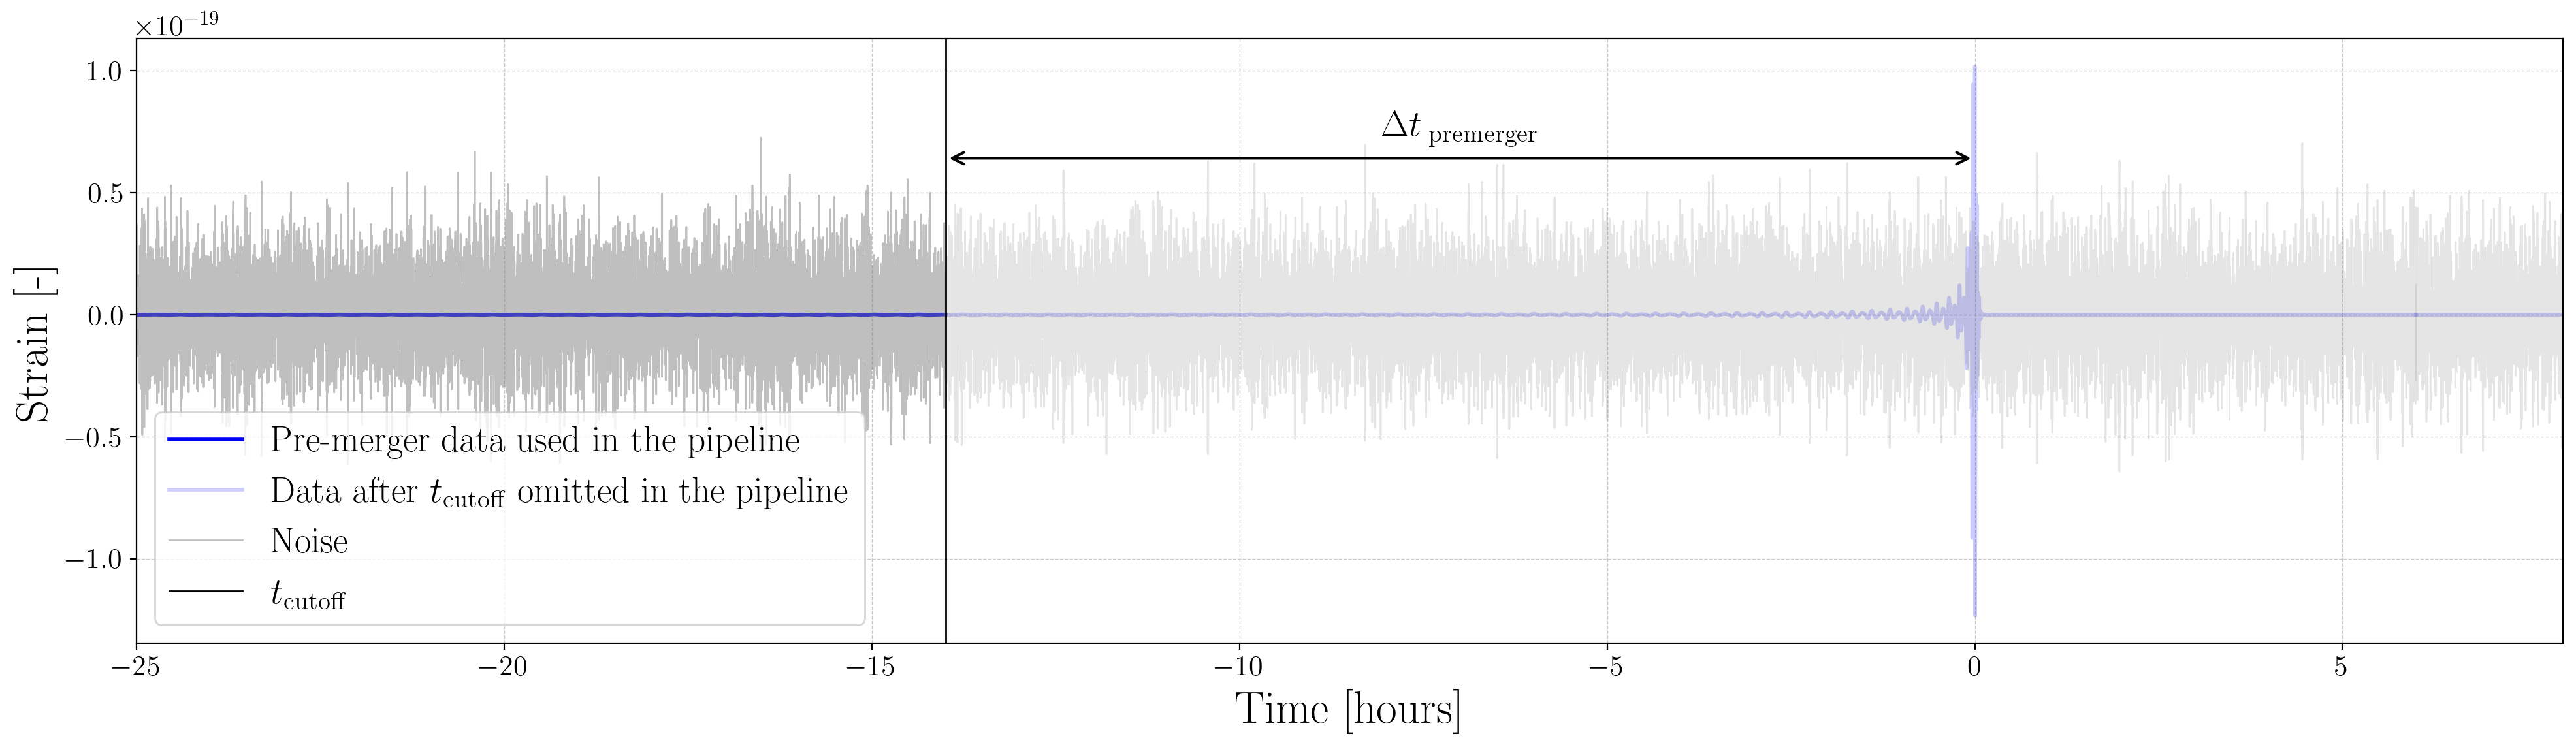

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# convert time to months
time = np.arange(len(wave_time_domain[0])) * dt - t_ref  # Shift time so that t_ref is at 0 seconds
seconds_per_month = 1 * 3600  # 30 days in seconds
time_hours = time / 3600

# Define your truncation boundaries
t_start = 0 - 14*60*60  # 14 hours before merger
t_end   = 0 + 6*60*60   # 6 hours after merger

# Convert to months
t_start_months = t_start / seconds_per_month
t_end_months   = t_end / seconds_per_month
t_ref_months   = t_ref / seconds_per_month

# Create masks for pre- and post-truncation regions
mask_before = time < t_start
mask_window = (time >= t_start) & (time <= t_end)
mask_after  = time > t_end

plt.figure(figsize=(20,6))

# Plot data before the window (faded)
plt.plot(time_hours[mask_before], wave_time_domain[1][mask_before],
         color='blue', lw=2, label='Pre-merger data used in the pipeline')

# Plot data inside the 20-hour window (highlighted)
plt.plot(time_hours[mask_window], wave_time_domain[1][mask_window],
         color='blue', alpha=0.2, lw=2.0, label=r'Data after $t_{\rm cutoff}$ omitted in the pipeline')

# Optional: plot data after window (faded)
plt.plot(time_hours[mask_after], wave_time_domain[1][mask_after],
         color='blue', alpha=0.2, lw=2.0)

# Noise in background
plt.plot(time_hours[mask_before], noises[0][mask_before], color='gray', alpha=0.5, lw=1, label='Noise')
plt.plot(time_hours[mask_window], noises[0][mask_window], color='gray', alpha=0.2, lw=1)
plt.plot(time_hours[mask_after], noises[0][mask_after], color='gray', alpha=0.2, lw=1)

# Vertical lines
plt.axvline(t_start_months, color='k', lw=1, label=r'$t_{\rm cutoff}$')
#plt.axvline(t_end_months,   color='k', ls='--', lw=1, label=r'$t_{\rm end}$')

# Labels at the bottom
y_text = min(wave_time_domain[1]) #- 5e-21
x_text = 2500 / seconds_per_month  # adjust for months
#plt.text(t_start_months+x_text, y_text, r'$t_{\rm cutoff}$', ha='center', va='top', fontsize=12)
#plt.text(t_end_months+x_text-0.2,   y_text, r'$t_{\rm end}$',   ha='center', va='top', fontsize=15)

# Horizontal arrow indicating the 20-hour window
y_arrow = max(wave_time_domain[1][mask_window])*0.9
# plt.annotate(
#     '', xy=(t_end_months, y_arrow), xytext=(t_start_months, y_arrow),
#     arrowprops=dict(arrowstyle='<->', color='k', lw=1.5)
# )
# plt.text((t_start_months+t_end_months)/2, y_arrow*1.05, r'$\Delta t_{\rm prior}$', ha='center', va='bottom', fontsize=20)

# Horizontal arrow from t_start to 0
plt.annotate(
    '', xy=(0/seconds_per_month, y_arrow*0.7), xytext=(t_start_months, y_arrow*0.7),
    arrowprops=dict(arrowstyle='<->', color='k', lw=1.5)
)
plt.text((t_start_months + 0/seconds_per_month)/2, y_arrow*0.75, r'$\Delta t_{\rm\; premerger}$', ha='center', va='bottom', fontsize=20)


# Labels, title, grid
plt.xlabel('Time [hours]', fontsize=25)
plt.ylabel('Strain [-]', fontsize=25)
#plt.title('Time-Domain Pre-Merger Signal', fontsize=16)
plt.grid(True, ls='--', lw=0.5, alpha=0.7)

# Legend
plt.legend(loc='lower left', fontsize=20, frameon=True)
plt.xlim((0 - 60*60*25)/seconds_per_month, (0 + 8*60*60)/seconds_per_month)
plt.tight_layout()

#plt.savefig('waveform_time_domain_zoomed.pdf', dpi=300)
plt.show()


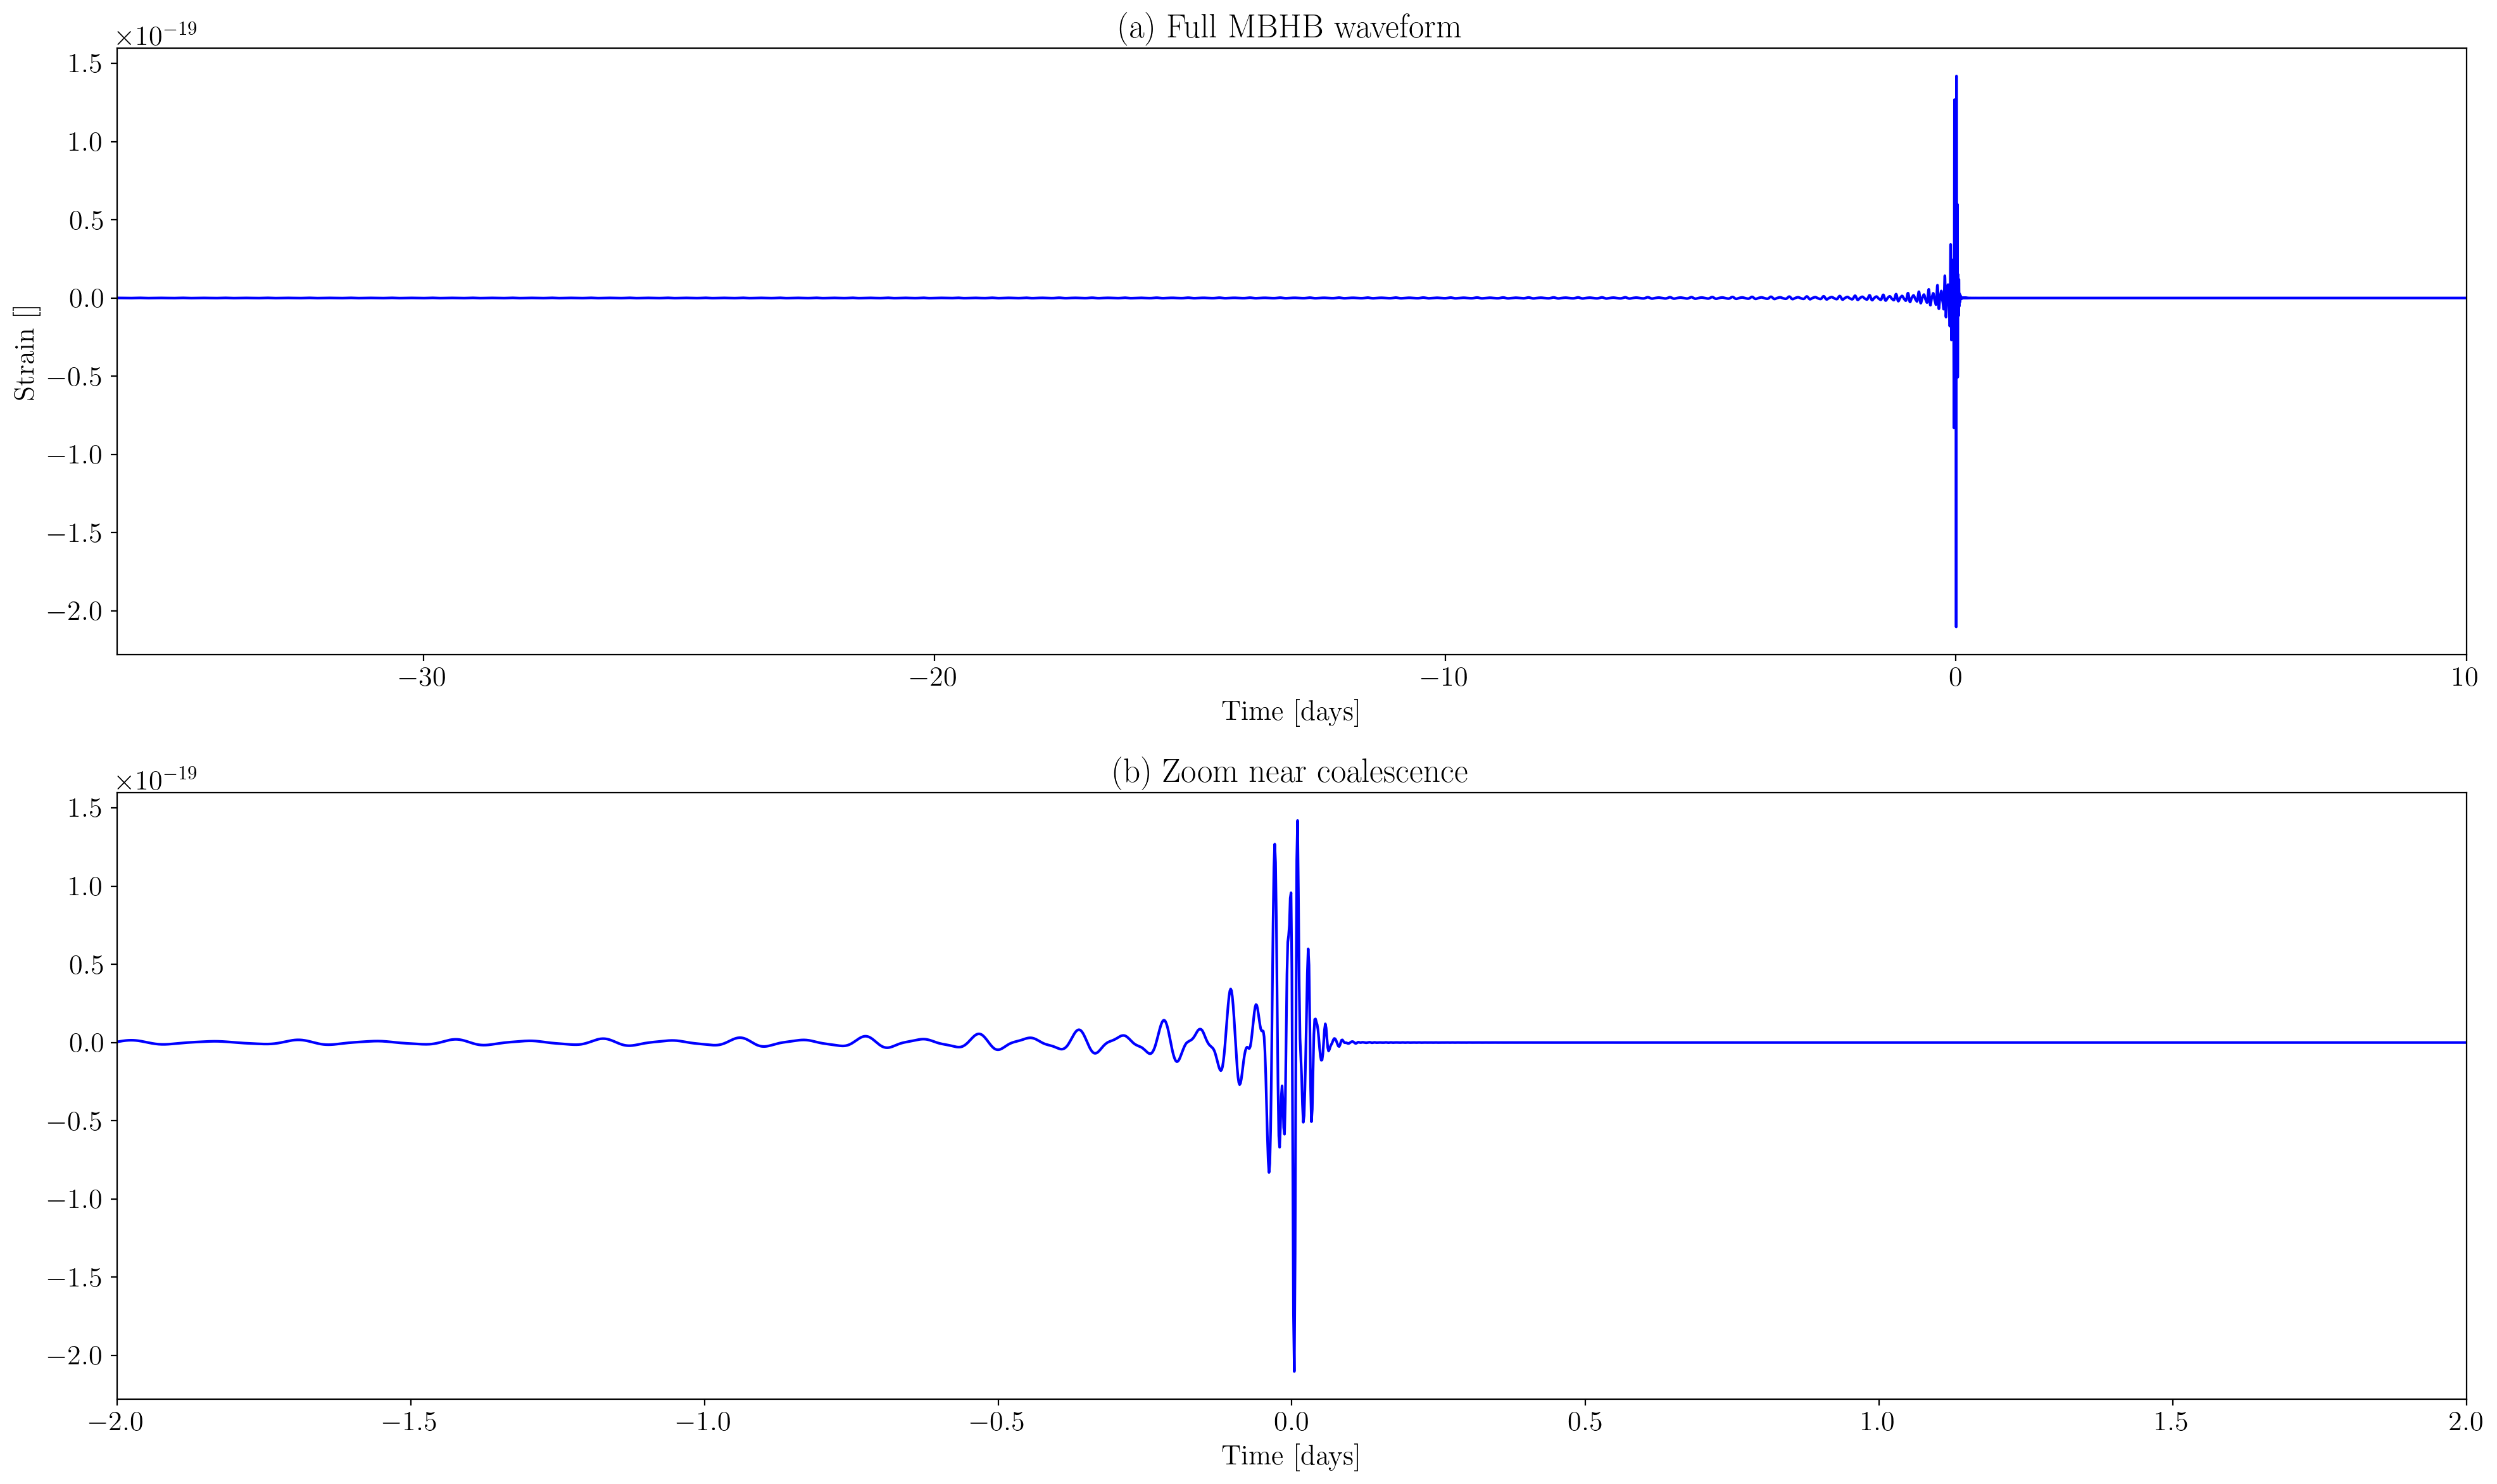

In [ ]:
plt.figure(figsize=(12, 6))
time_days = time_hours/24
# Noise (muted, semi-transparent)
plt.plot(time_days, noises[1], label='Noise',
         color='gray', alpha=0.5, lw=1)

# Signal (bold, stands out)
plt.plot(time_days, wave_time_domain[0], label='MBHB Signal',
         color='blue', lw=2)

# Coalescence marker
plt.axvline(0, color='k', ls='--', lw=1, label=r'$t_c$')

# Labels & limits
plt.xlabel('Time [s]', fontsize=14)
plt.ylabel('Strain []', fontsize=14)
plt.title('MBHB Waveform in the Time Domain', fontsize=16)

plt.xlim(-36, 10)

# Grid & legend
plt.grid(True, ls='--', lw=0.5, alpha=0.7)
plt.legend(loc='lower left', fontsize=12, frameon=False)

plt.tight_layout()
plt.show()

In [17]:
def generate_noise(N, dt, sens_mat, seed=None):
    if seed is not None:
        np.random.seed(seed)
    noises = []
    for sens_fn in sens_mat.sens_mat:
        noise = np.fft.irfft(np.random.normal(0.0, np.sqrt(sens_fn))
                             +1j * np.random.normal(0.0, np.sqrt(sens_fn))
                            ) /np.sqrt(dt*4/N)
        noises.append(noise)
    noises = np.array(noises)
    return noises

DAY_SI = 24*3600
Tobs = YRSID_SI + 5*DAY_SI
dt = 5.
N = int(Tobs / dt)
Tobs = N * dt
freq = np.fft.rfftfreq(N,dt)
freq[0] = freq[1]

wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), use_gpu=False)

m1 = 1e5
m2 = 1e5
chi1z = 0.0
chi2z = 0.7
dist = 2 * 1e9 * PC_SI
phi_ref = 1.0
f_ref = 1.0
inc = 2*np.pi/3.
beta= 0
lam = 0
psi = np.pi
t_ref = Tobs - 60*60*24 - 5*DAY_SI

modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

wave_freq_domain = wave_gen(m1, m2, chi1z, chi2z,
                            dist, phi_ref, f_ref, inc, lam,
                            beta, psi, t_ref, 
                            freqs=freq, modes=modes, 
                            direct=False, fill=True, squeeze=True, length=1024)[0]
wave_time_domain = np.fft.irfft(wave_freq_domain, axis=-1)
noises = generate_noise(N, dt, AET1SensitivityMatrix(freq), seed=0)
wave_time_domain_with_noise = wave_time_domain + noises

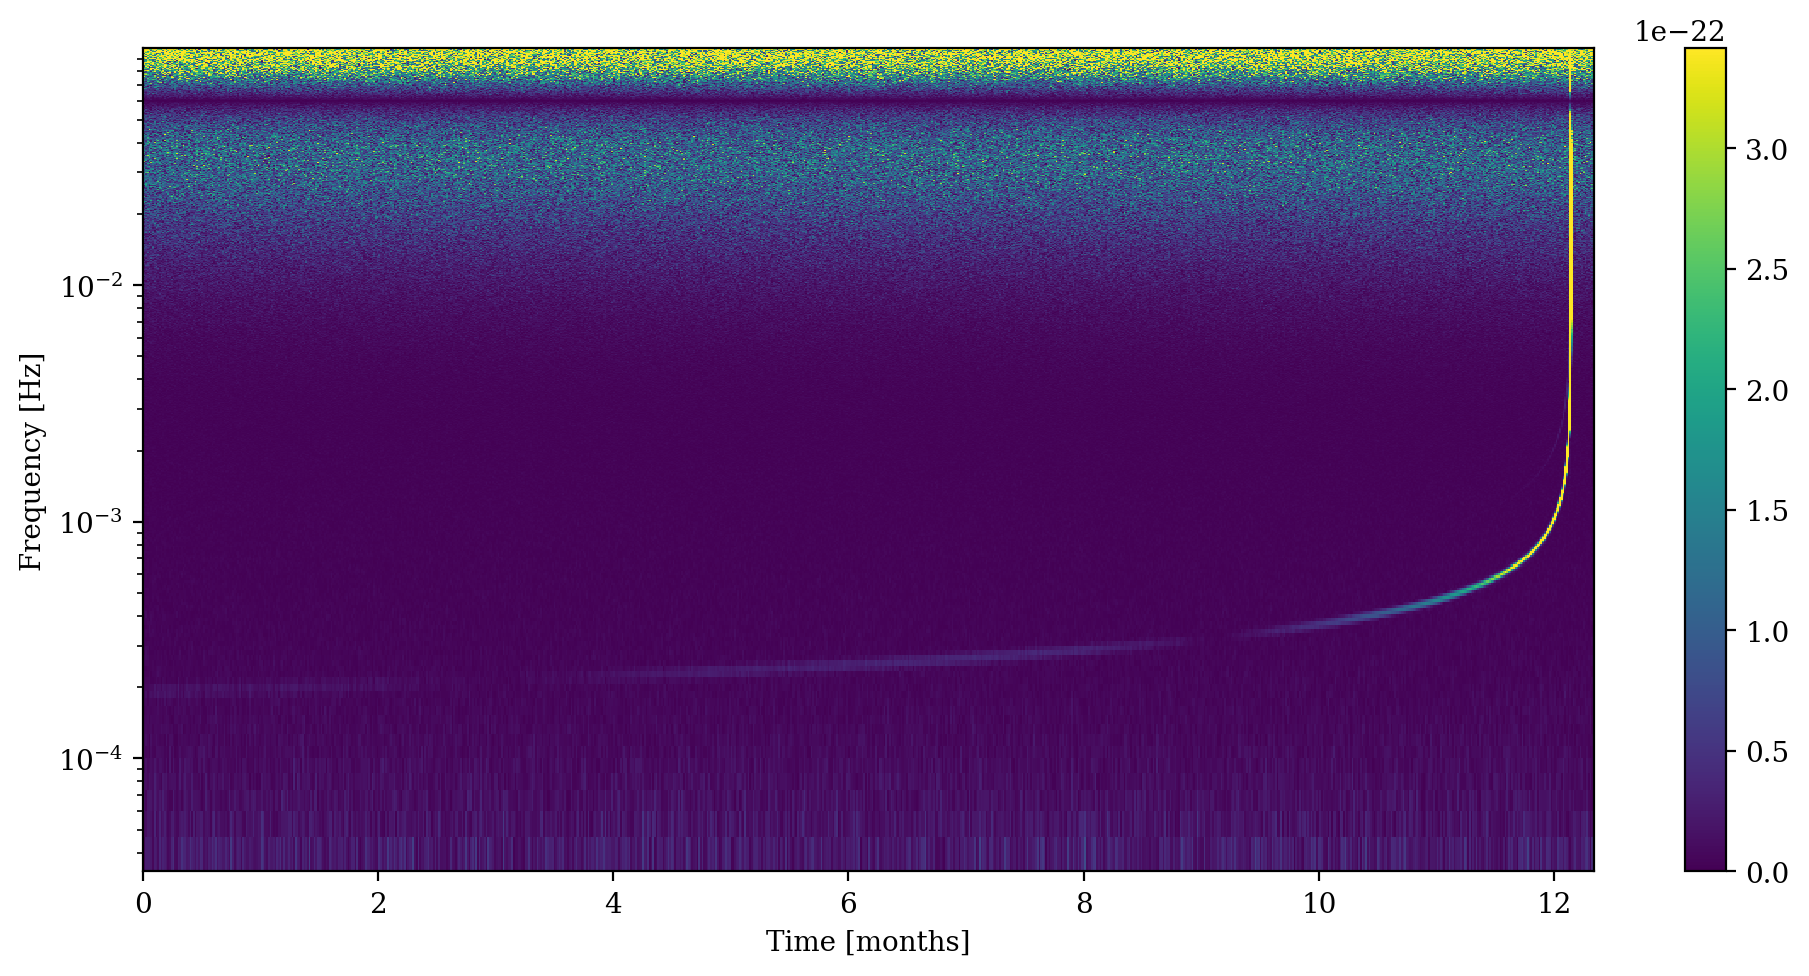

In [ ]:
f, t, Zxx = sp.signal.stft(wave_time_domain_with_noise[1], fs=1/dt, nperseg=15000,)
max_freq = 0.1
max_freq_idx = np.searchsorted(f, max_freq)
min_freq = 3e-5  #3e-5
min_freq_idx = np.searchsorted(f, min_freq)

# Convert t to months before plotting
t_months = t / (30 * 24 * 3600)

plt.figure(figsize=(10, 5))
plt.pcolormesh(t_months, f[min_freq_idx:max_freq_idx], np.abs(Zxx[min_freq_idx:max_freq_idx]), vmin=0, 
               vmax= np.max(np.abs(Zxx[min_freq_idx:max_freq_idx]))/20,
               rasterized=True,
)
plt.yscale('log')
plt.xlim(t_months[0], t_months[-2])
#plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [months]')
plt.colorbar()
plt.tight_layout()
plt.savefig("thesis_figures/sftf_modulation_1e-5.pdf")
plt.show()

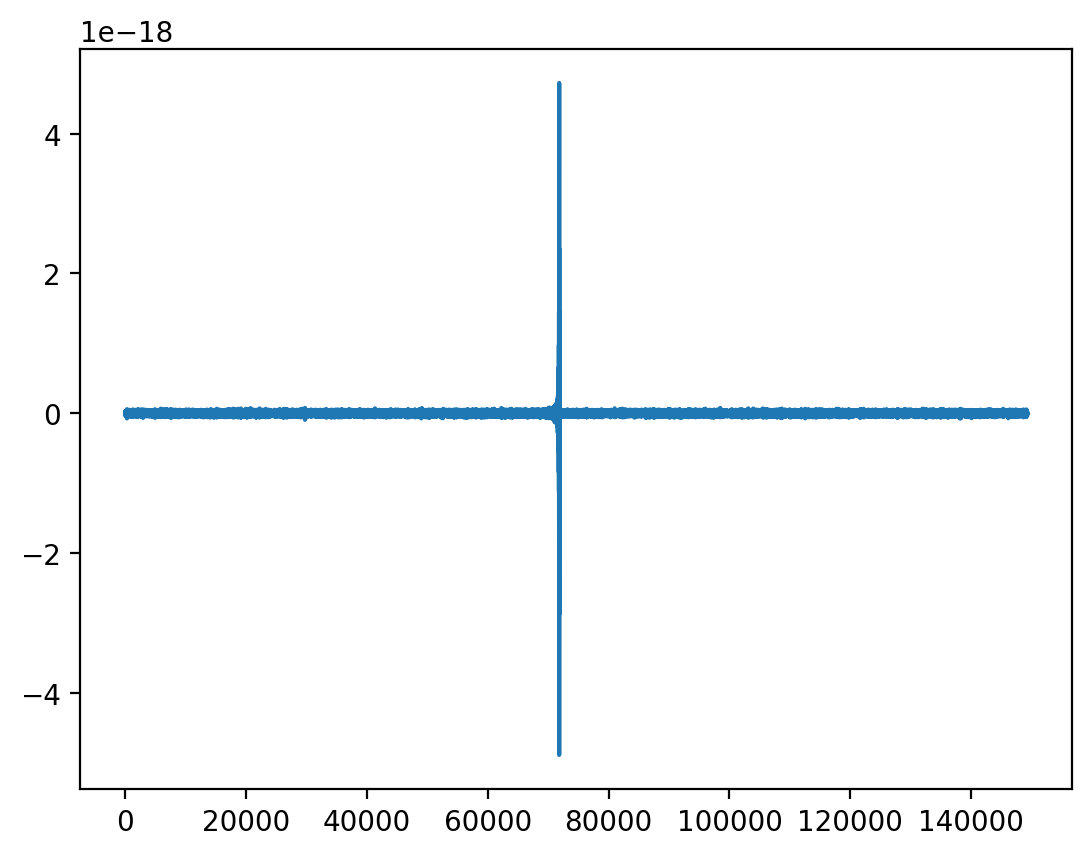

In [76]:
def post_observation(gravitational_wave_data_t, t_array, cutoff_index):
        data_t_post_observation = gravitational_wave_data_t[:, cutoff_index:]
        t_array_post_observation = t_array[cutoff_index:]

        return data_t_post_observation, t_array_post_observation

data_t_post_observation, t_array_post_observation =  post_observation(data_t, t_array, cutoff_index)
plt.plot(data_t_post_observation[0])

(151,) (501,)


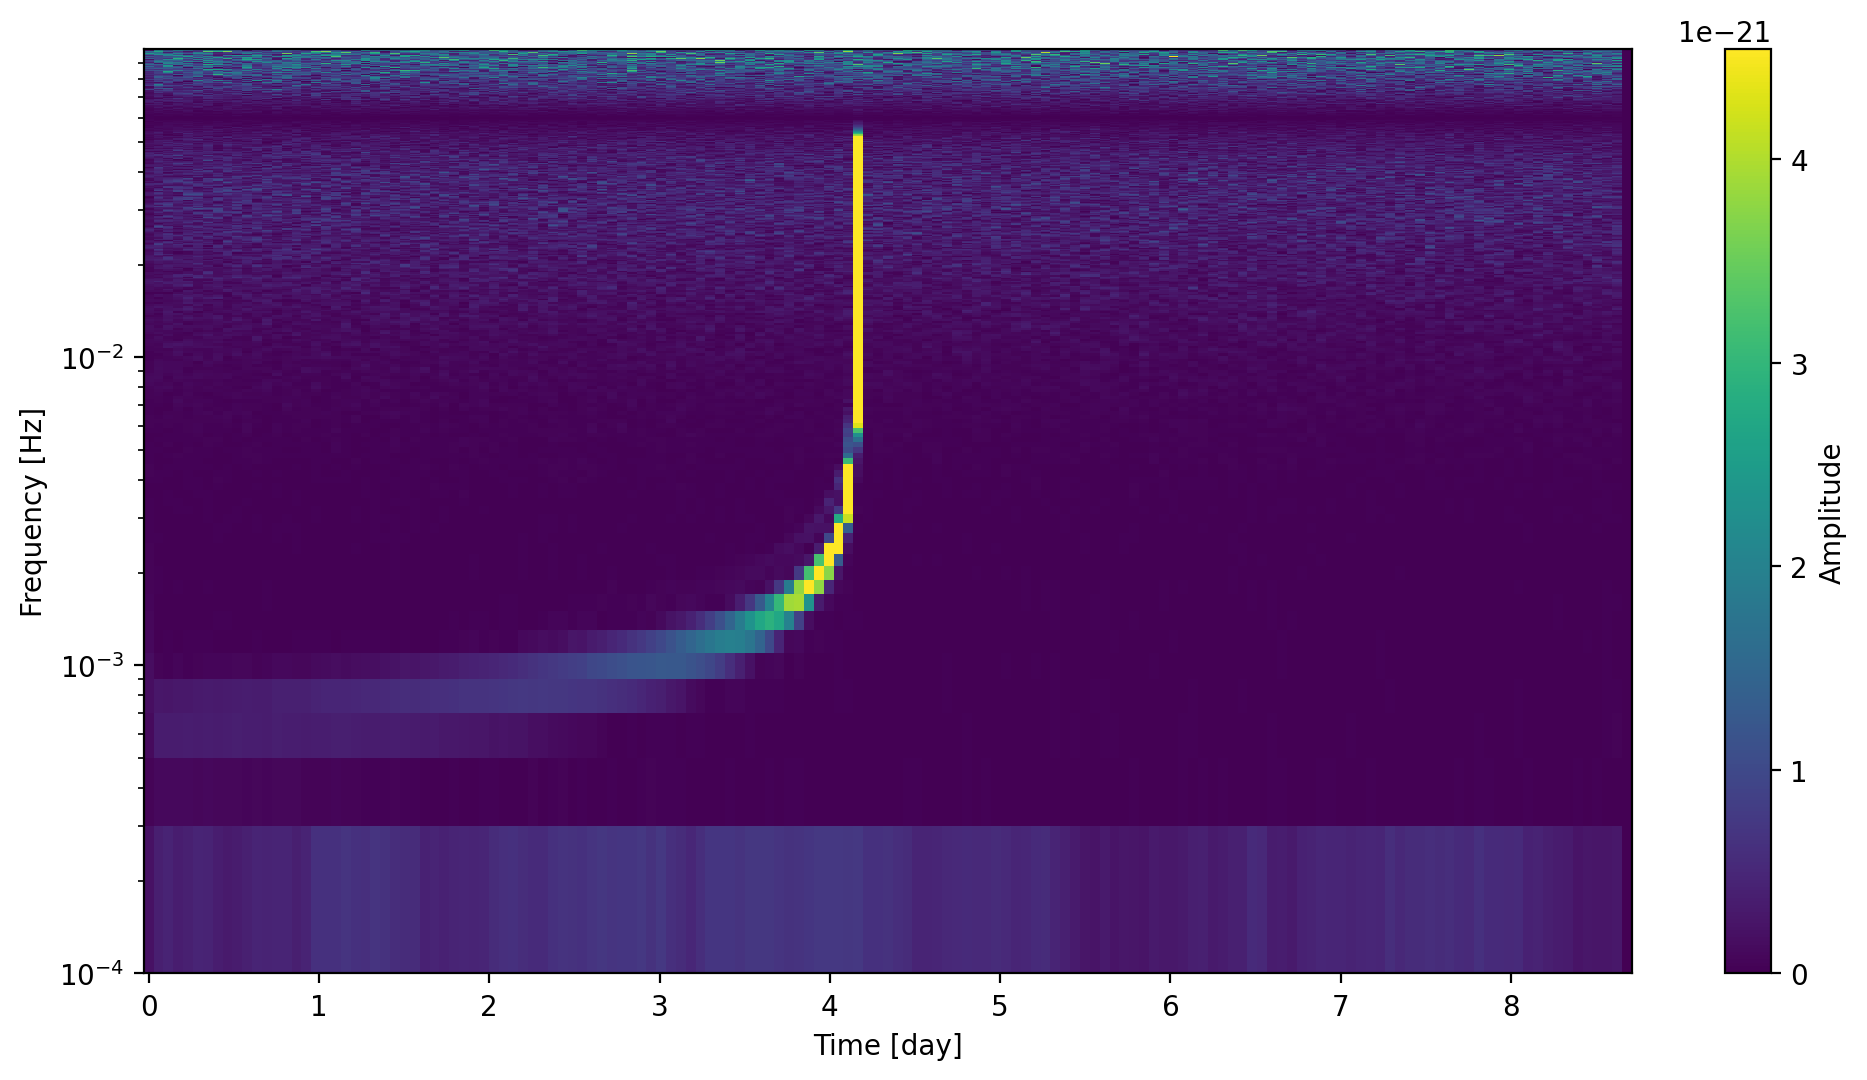

In [77]:
f, t, Zxx = sp.signal.stft(data_t_post_observation[0], fs=1/sim.dt, nperseg=1000, noverlap=0)

print(t.shape, f.shape)

max_freq_idx = np.searchsorted(f, 1e-1)
min_freq_idx = np.searchsorted(f, 1e-4)

plt.figure(figsize=(12, 6))
plt.pcolormesh(t/(3600*24), f[min_freq_idx:max_freq_idx], np.abs(Zxx[min_freq_idx:max_freq_idx]), vmin=0,
               vmax=np.max(np.abs(Zxx[min_freq_idx:max_freq_idx]))/10)
plt.yscale('log')
#plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [day]')
#plt.axvline(t_ref, color='w', linewidth=0.5)
cbar = plt.colorbar()
cbar.set_label("Amplitude") 


# Spectrogram

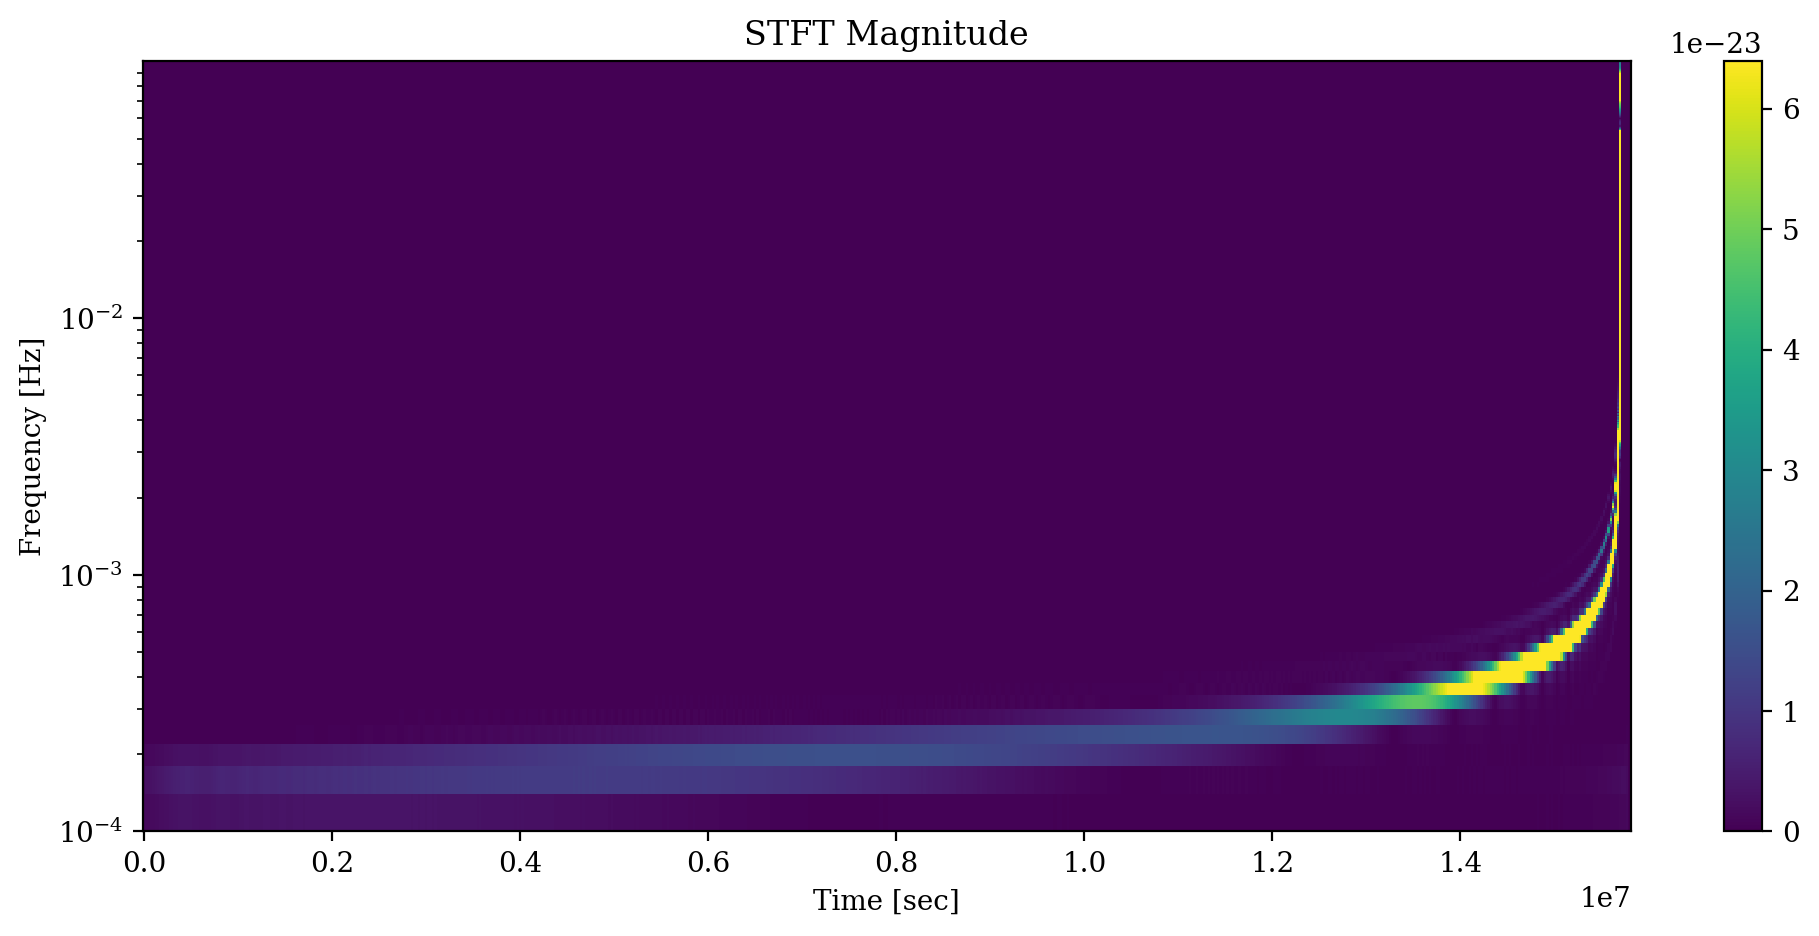

In [15]:
Tobs = 6*YRSID_SI/12
dt = 5.
include_T_channel = False # Set to True if you want to include the T channel in the simulation, otherwise only A and E channels will be included.

wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), use_gpu=gpu)

sim = LISASimulator(Tobs=Tobs, dt=dt, wave_gen=wave_gen, include_T_channel=include_T_channel)

m1 = 3e5
m2 = 1.5e5
a1 = 0.753
a2 = 0.621
dist = 10 * PC_SI * 1e9
phi_ref = 0.0 #np.pi/2
f_ref = 0.0
inc = 0.224
lam = 60*(np.pi/180)
beta = 20*(np.pi/180)
psi = 0
t_ref = Tobs - (24*60*60)

parameters = np.array([m1, m2, a1, a2, dist, phi_ref, f_ref, inc, lam, beta, psi, t_ref])

modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]
waveform_kwargs = dict(length=1024, direct=False, fill=True, squeeze=False, modes=modes)

data_t, data_f, f_array, t_array, sens_mat = sim(seed = 42, parameters=parameters, waveform_kwargs=waveform_kwargs)
waveform_kwargs.update(freqs=f_array)

f, t, Zxx = sp.signal.stft(sim.signal_t[0,0], fs=1/sim.dt, nperseg=5000, noverlap=0)

max_freq_idx = np.searchsorted(f, 0.1)
min_freq_idx = np.searchsorted(f, 1e-4)

plt.figure(figsize=(12, 5))
plt.pcolormesh(t, f[min_freq_idx:max_freq_idx], np.abs(Zxx[min_freq_idx:max_freq_idx]), vmin=0,
               vmax=np.max(np.abs(Zxx[min_freq_idx:max_freq_idx]))/100)
plt.yscale('log')
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
#plt.axvline(t_ref, color='w', linewidth=0.5)
plt.colorbar()

(7501,) (419,) 3142919


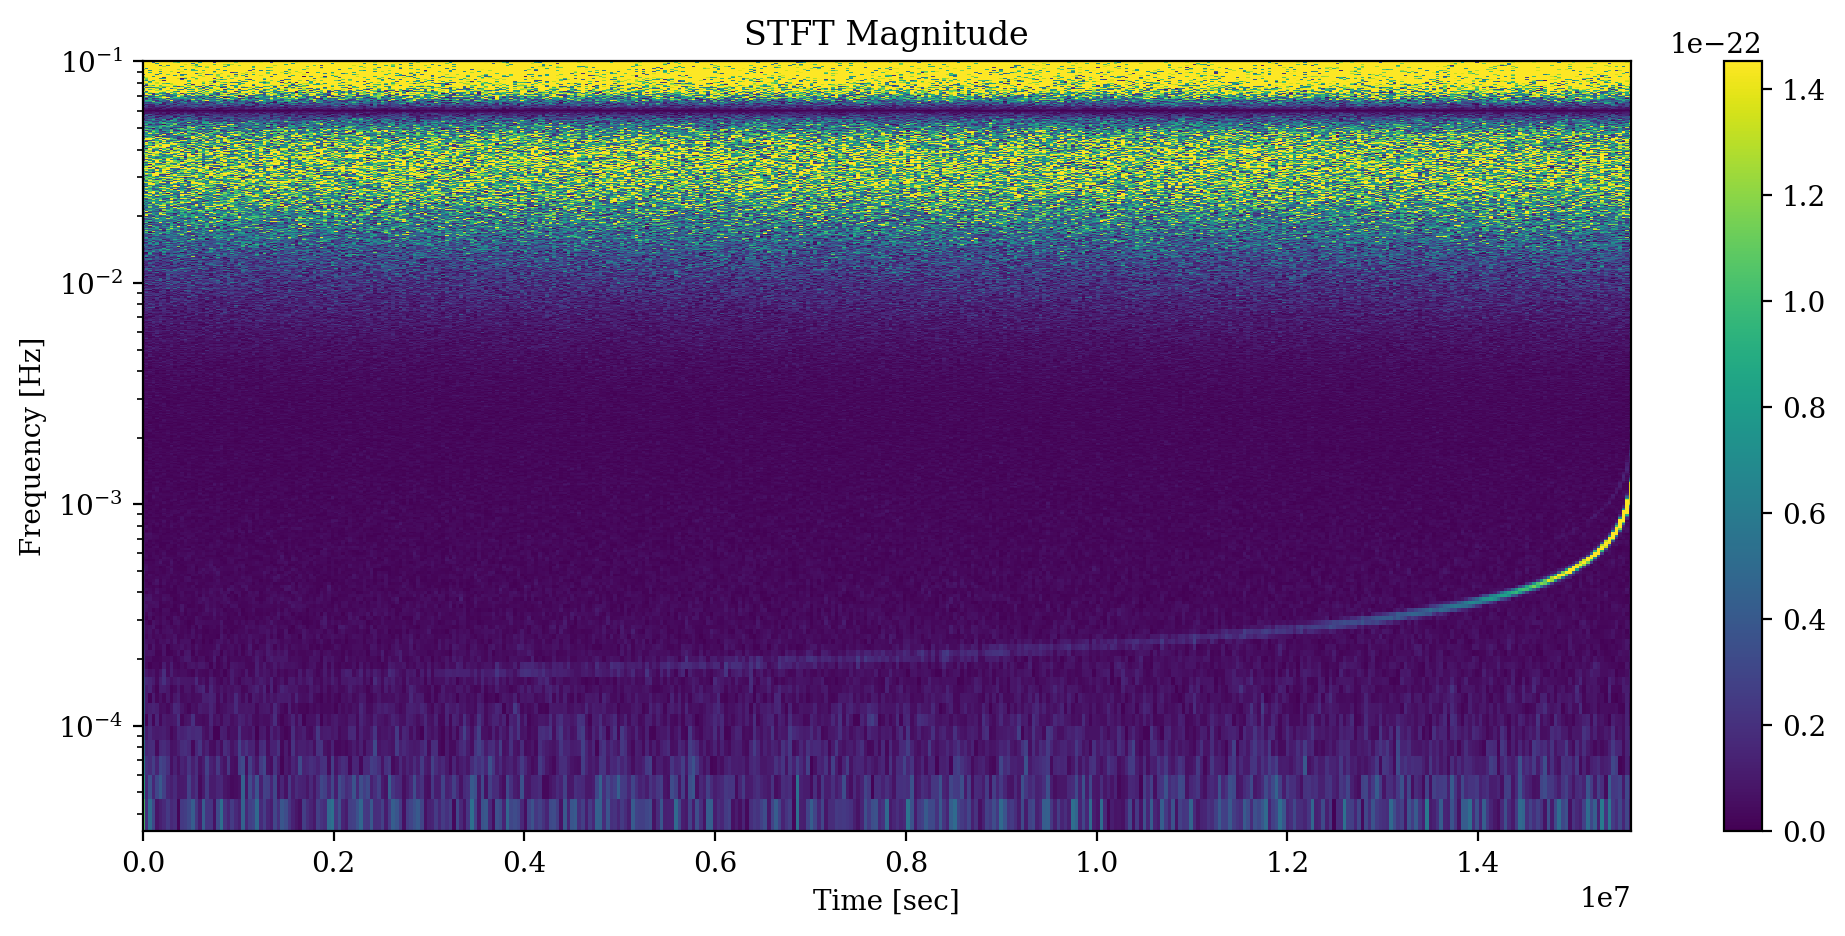

In [45]:
# Not doing the premerger now to see if the code works better with the merger included
hours_before_merger = 10
time_before_merger = hours_before_merger*60*60
cutoff_time = t_ref - time_before_merger
width_of_tref_prior = 20
max_time = t_ref + (width_of_tref_prior - hours_before_merger)*60*60

def pre_merger(gravitational_wave_data_t, time_before_merger, t_ref, t_array):
        cutoff_time = t_ref - time_before_merger
        cutoff_index = np.searchsorted(t_array, cutoff_time)
        data_t_truncated = gravitational_wave_data_t[:, :cutoff_index]
        return data_t_truncated, cutoff_index

data_t_truncated,   cutoff_index =  pre_merger(data_t, time_before_merger, t_ref, t_array)
signal_t_truncated, cutoff_index =  pre_merger(sim.signal_t[0], time_before_merger, t_ref, t_array)

f, t, Zxx = sp.signal.stft(data_t_truncated[0], fs=1/sim.dt, nperseg=15001, )

print(f.shape, t.shape, f.shape[0]*t.shape[0])

max_freq_idx = np.searchsorted(f, 0.1)
min_freq_idx = np.searchsorted(f, 3e-5)

plt.figure(figsize=(12, 5))
plt.pcolormesh(t, f[min_freq_idx:max_freq_idx], np.abs(Zxx[min_freq_idx:max_freq_idx]), vmin=0,
               vmax=np.max(np.abs(Zxx[min_freq_idx:max_freq_idx]))/10)
plt.yscale('log')
plt.xlim(0, t[-3])
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar()

# 14 hours before merger

# Presentation Plots

In [1]:
from tools.likelihood import TimeFreqSNR
analysis = TimeFreqSNR(
    data_t=data_t_truncated,
    wave_gen=wave_gen,
    nperseg=1414,
    dt_full=dt,
    cutoff_index=cutoff_index,
    pre_merger=True
)
analysis.get_stft_of_data()
SNR, amplitude = analysis.calculate_time_frequency_SNR(*parameters, waveform_kwargs=waveform_kwargs)
new_distance = dist /  amplitude
print((new_distance - dist)/(PC_SI*1e9) , (new_distance-dist)/dist)
print( "True distance       = ",  dist/(PC_SI*1e9), "Gpc")
print( "Dist from Amplitude = ",  new_distance/(PC_SI*1e9), "Gpc")
print( "SNR calculated      = ",  SNR)

NameError: name 'data_t_truncated' is not defined

In [ ]:
f, t, Zxx = sp.signal.stft(data_t_truncated[0], fs=1/sim.dt, nperseg=2081, noverlap=0)

print(t.shape, f.shape)

max_freq_idx = np.searchsorted(f, 0.1)
min_freq_idx = np.searchsorted(f, 1e-4)

plt.figure(figsize=(12, 5))
plt.pcolormesh(t, f[min_freq_idx:max_freq_idx], np.abs(Zxx[min_freq_idx:max_freq_idx]), vmin=0,
               vmax=np.max(np.abs(Zxx[min_freq_idx:max_freq_idx]))/10)
plt.yscale('log')
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
#plt.axvline(t_ref, color='w', linewidth=0.5)
plt.colorbar()

In [ ]:
max_index = np.argmax(wave_full)
print("Index of max value in wave_truc:", max_index)

In [ ]:
wave_full = sim.signal_t[0,0]
max_index = np.argmax(wave_full)
delta_left = 2000
delta_right = 1500
wave_truc = wave_full[max_index-delta_left:max_index+delta_right]
split_index = 800
wave_truc_part_1 = wave_truc.copy()
wave_truc_part_1[split_index:] = np.nan
wave_truc_part_2 = wave_truc.copy()
wave_truc_part_2[:split_index] = np.nan
tarray_truncated = np.arange(len(wave_truc)) 
max_index_truc = np.argmax(wave_truc)
delta_trunc = 800
plt.figure(figsize=(12, 5))
plt.plot(tarray_truncated, wave_truc_part_1, color='black', alpha=0.5)
plt.plot(tarray_truncated, wave_truc_part_2, color='black', alpha=1)
plt.xlim(0, len(wave_truc))
plt.axvline(max_index_truc-delta_trunc)
plt.axvline(max_index_truc+delta_trunc)

# CHARACTERISTIC STRAIN

In [5]:
# imports 
from lisatools.sensitivity import get_sensitivity
from bbhx.waveforms.phenomhm import PhenomHMAmpPhase
from matplotlib import rc
"""
rc('font', **{
 'family': 'serif',
 'serif': ['Computer Modern Roman'],
 })
rc('text', usetex=True)
"""
import matplotlib.pyplot as plt

wave_gen_frequency = PhenomHMAmpPhase()

# PhenomHMAmpPhase by itself generates PhenomHM waveforms in the amplitude and phase representation WITHOUT LISA RESPONSE!
# LISA reponse = AET channels =  what we see in the detector. This is what we care about. This is added in BBHWaveformFD
# BBHWaveformFD also uses PhenomHMAmpPhase to generate the waveforms, but it also adds the LISA response.

Tobs =  2*YRSID_SI # seconds
dt = 5.  # sec
m1 = 2e5
m2 = 2e5
a1 = 0.753
a2 = 0.621
dist = 10 * PC_SI * 1e9
phi_ref = 0.0 #np.pi/2
f_ref = 0.0
inc = 0.224
lam = 60*(np.pi/180)
beta = 90*(np.pi/180)
psi = 0
t_ref = Tobs - (2*60*60)
length = 1024               # THIS WAS SO CONFUSING BECAUSE I DIDN'T READ THE DOCUMENTATION PROPERLY (See comments in the BBHWaveformFD cell)
parameters = np.array([m1, m2, a1, a2, dist, phi_ref, f_ref, inc, lam, beta, psi, t_ref])
modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]
waveform_kwargs = dict(length=1024, direct=False, fill=True, squeeze=False, modes=modes)

wave_gen_frequency(m1, m2, a1, a2, dist, phi_ref, f_ref, t_ref, length)


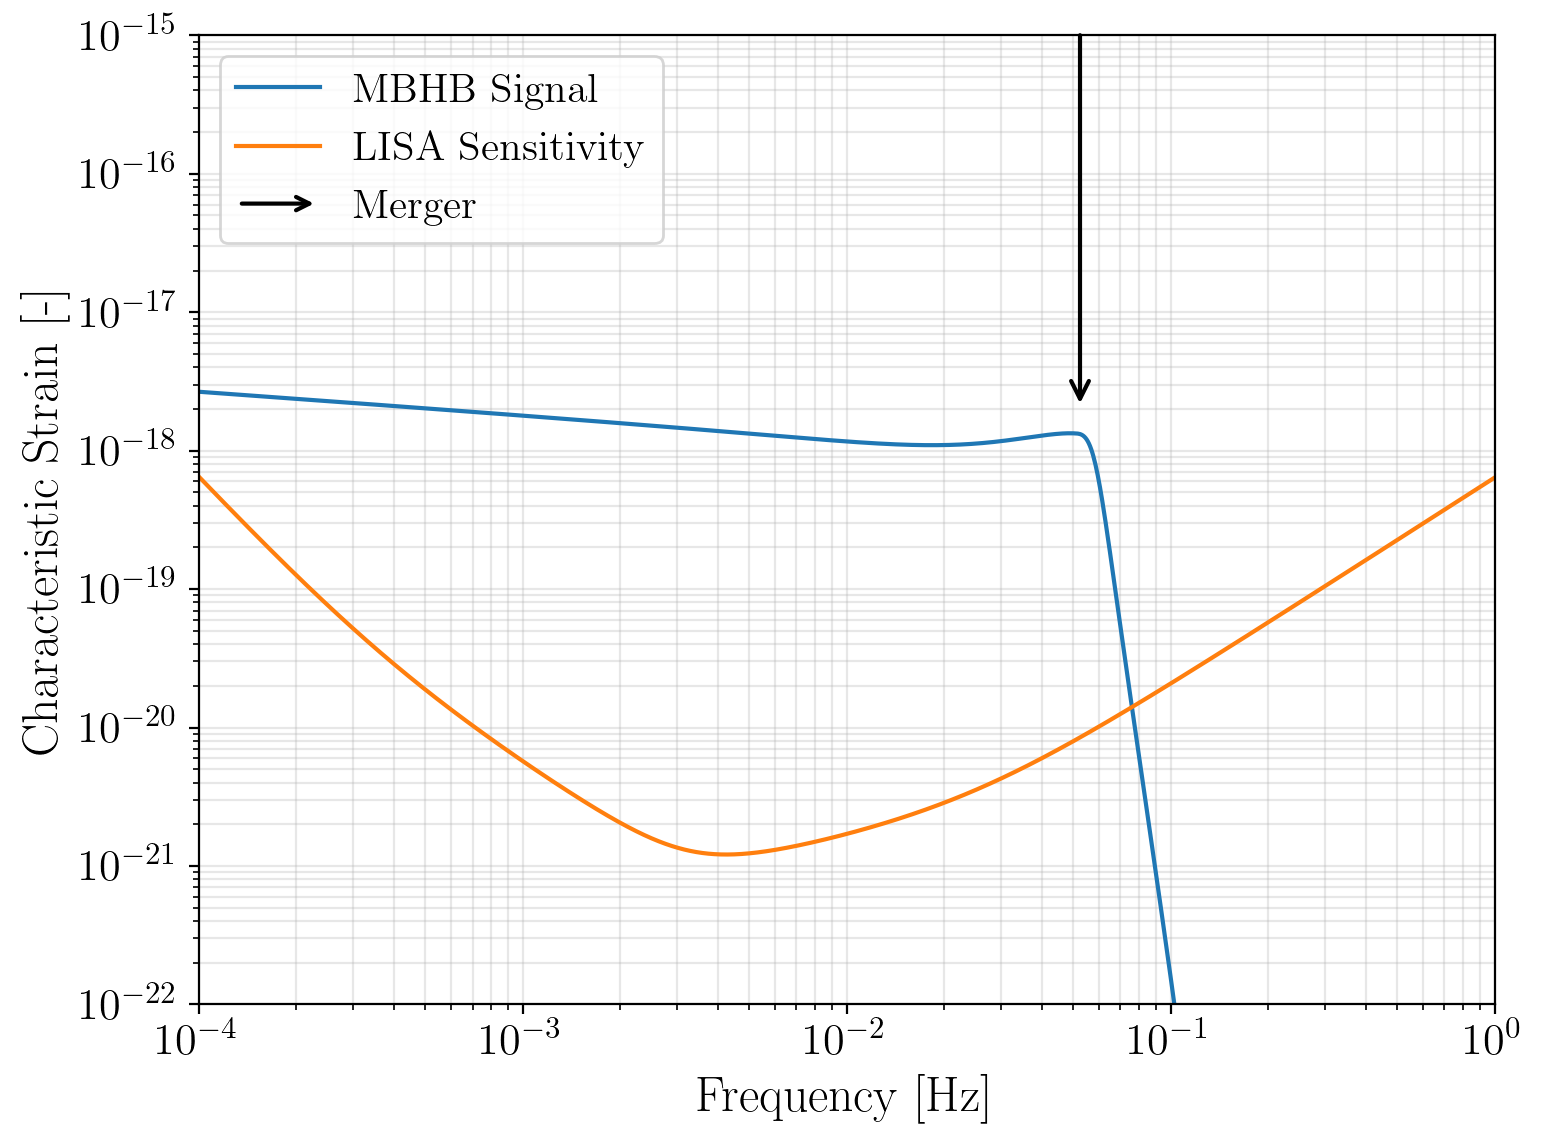

In [79]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fn = np.logspace(-4, 1, 10000)
Sn_char_strain = get_sensitivity(fn, sens_fn="LISASens", return_type="char_strain") 

modes = [(2,2)]

figure_scale = 1
plt.figure(figsize=(8/figure_scale, 6/figure_scale))
for i, mode in enumerate(modes):
    char_strain = wave_gen_frequency.freqs_shaped[0, i] * wave_gen_frequency.amp[0, i]
    plt.loglog(wave_gen_frequency.freqs_shaped[0, i], char_strain, label='MBHB Signal')

index_of_coalescence = 800

# Draw the arrow showing merger
plt.annotate('', 
    xy=(wave_gen_frequency.freqs_shaped[0, 0][index_of_coalescence], 2e-18),
    xytext=(wave_gen_frequency.freqs_shaped[0, 0][index_of_coalescence], 1.1e-15),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5)
)

# Add the LISA sensitivity curve
plt.loglog(fn, Sn_char_strain, label="LISA Sensitivity")

# Create a thin custom legend arrow
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch

class HandlerArrow(HandlerPatch):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        # Center the arrow vertically and scale it
        center = ydescent + height / 2.
        p = FancyArrowPatch(
            (xdescent, center),
            (xdescent + width, center),
            mutation_scale=12,
            color=orig_handle.get_facecolor(),
            lw=1.5,
            arrowstyle=orig_handle.get_arrowstyle(),
            transform=trans,
        )
        return [p]

# Create your arrow handle
arrow_handle = FancyArrowPatch(
    (0, 0), (1, 0),
    color='black',
    lw=1.5,
    arrowstyle='->',
)

# Combine legend entries
handles, labels = plt.gca().get_legend_handles_labels()
handles.append(arrow_handle)
labels.append("Merger")

# Use custom handler to render arrow cleanly (no box)
plt.legend(handles, labels, handler_map={FancyArrowPatch: HandlerArrow()}, handlelength=2, loc='upper left', fontsize=15)

plt.xlabel("Frequency [Hz]", fontsize=18)
plt.ylabel("Characteristic Strain [-]", fontsize=18)
plt.ylim(1e-22, 1e-15)
plt.xlim(1e-4, 1e0)
plt.grid(which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("frequency_domain.pdf", dpi=300)
plt.show()


In [ ]:
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), use_gpu=False)

Tobs =  2*YRSID_SI / 12
dt = 5. 
N = int(int(Tobs / dt)/2)*2
freq = np.fft.rfftfreq(N,dt)
freq[0] = freq[1]

m1 = 2e5
m2 = 2e5
a1 = 0.753
a2 = 0.621
dist = 10 * PC_SI * 1e9
phi_ref = 0.0 #np.pi/2
f_ref = 0.0
inc = 0.224
lam = 60*(np.pi/180)
beta = 90*(np.pi/180)
psi = 0
t_ref = Tobs - 5*(24*60*60)

parameters = np.array([m1, m2, a1, a2, dist, phi_ref, f_ref, inc, lam, beta, psi, t_ref])

modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

wave_freq_domain = wave_gen(*parameters, 
                            freqs=freq, modes=modes, 
                            direct=False, fill=True, squeeze=True, length=1024)[0]

wave_time_domain = np.fft.irfft(wave_freq_domain, axis=-1)

f, t, Zxx = sp.signal.stft(wave_time_domain[1], fs=1/dt, nperseg=5000, noverlap=0)
max_freq = 0.1
max_freq_idx = np.searchsorted(f, max_freq)
min_freq = 1e-4  #3e-5
min_freq_idx = np.searchsorted(f, min_freq)

# Convert t to months before plotting
t_months = t / (24 * 3600)

plt.figure(figsize=(8, 6))
plt.pcolormesh(t_months, f[min_freq_idx:max_freq_idx], np.abs(Zxx[min_freq_idx:max_freq_idx]), vmin=0, 
               vmax= np.max(np.abs(Zxx[min_freq_idx:max_freq_idx]))/10,
               rasterized=True,
)
plt.yscale('log')
plt.xlim(t_months[0], t_months[-2])
#plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [days]')
plt.colorbar()
plt.tight_layout()
#plt.savefig("thesis_figures/timefrequency_domain.pdf")
plt.show()

AttributeError: module 'scipy.signal' has no attribute 'signal'

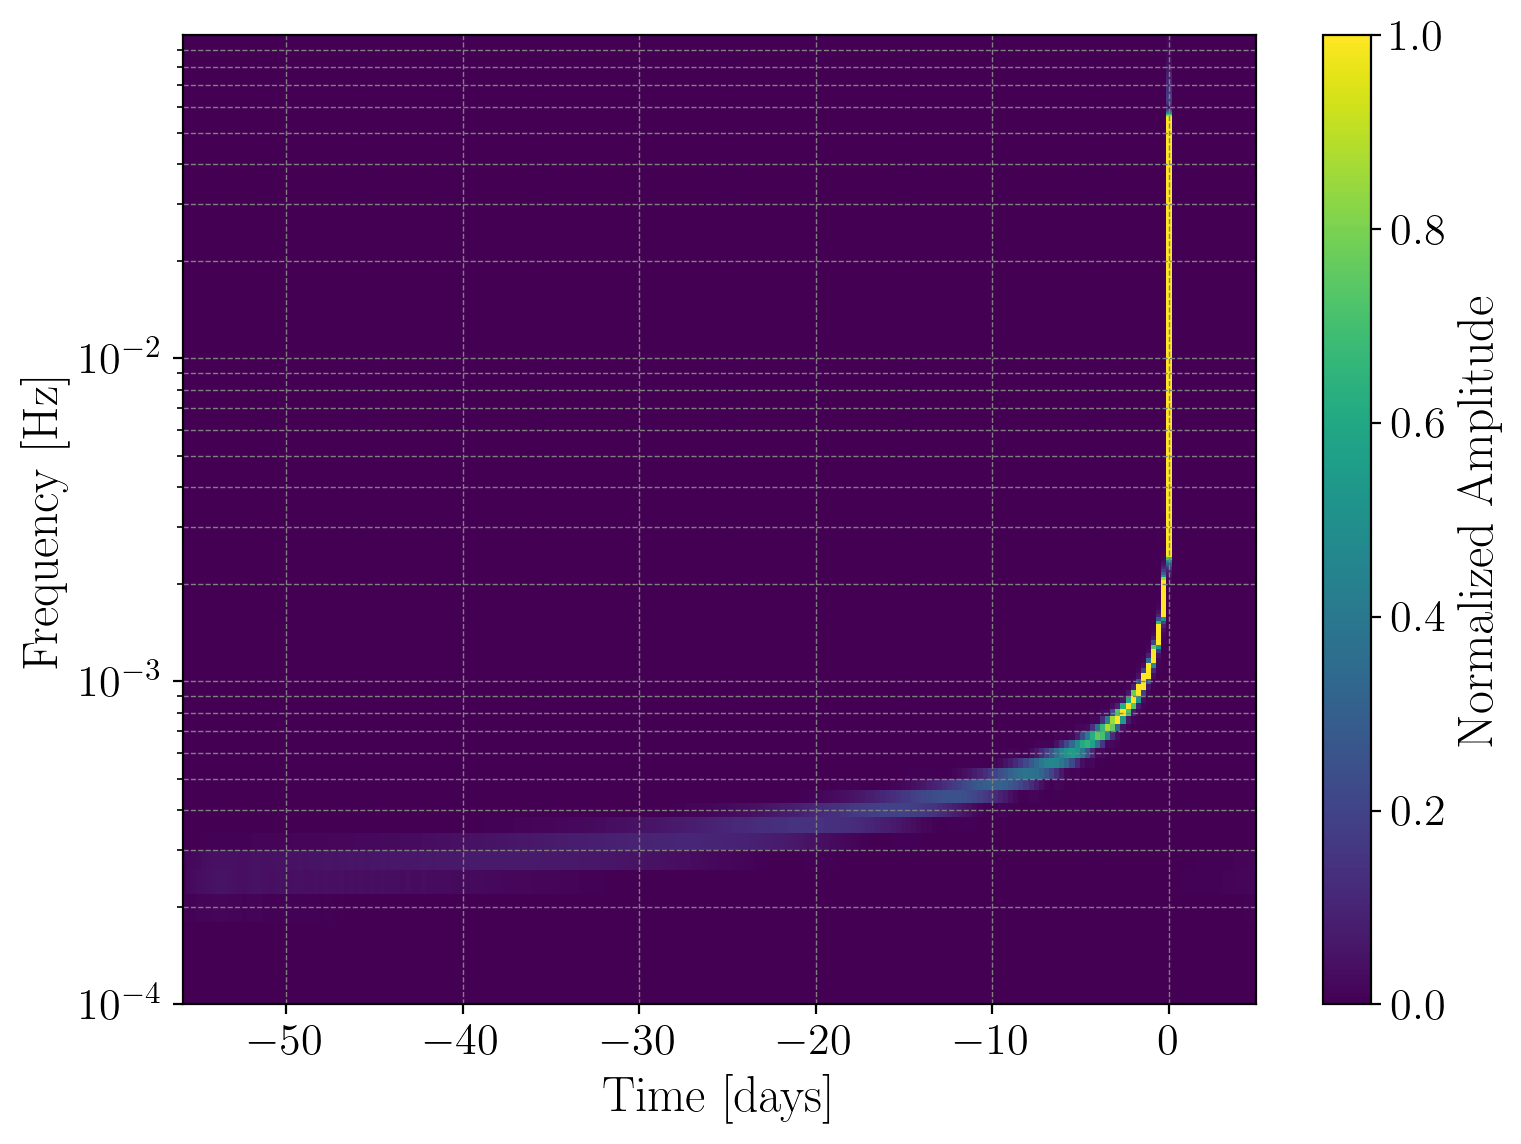

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sp

# Compute STFT
f, t, Zxx = sp.stft(wave_time_domain[1], fs=1/dt, nperseg=5000, noverlap=0)

# Frequency limits
max_freq = 0.1
max_freq_idx = np.searchsorted(f, max_freq)
min_freq = 1e-4
min_freq_idx = np.searchsorted(f, min_freq)

# Convert t to days or months (your variable name says months, but you're dividing by seconds)
t_days = t / (24 * 3600) - 55.844907407407405

# --- Normalize STFT magnitude ---
Zxx_mag = np.abs(Zxx[min_freq_idx:max_freq_idx])
Zxx_norm = Zxx_mag / np.max(Zxx_mag)  # normalize 0 → 1

# --- Plot normalized STFT ---
plt.figure(figsize=(8, 6))
plt.pcolormesh(
    t_days,
    f[min_freq_idx:max_freq_idx],
    Zxx_norm*20,
    vmin=0,
    vmax=1,  # now relative scale
    shading="auto",
    rasterized=True,
)

fontsize_plot = 18
plt.yscale('log')
plt.xlim(t_days[0], t_days[-2])
plt.ylabel('Frequency [Hz]', fontsize=fontsize_plot)
plt.xlabel('Time [days]', fontsize=fontsize_plot)
cbar = plt.colorbar()
cbar.set_label("Normalized Amplitude", fontsize=fontsize_plot)
plt.tight_layout()
plt.grid(
    which="both",
    color="gray",
    linestyle="--",
    linewidth=0.5,
    #alpha=0.3,
)
plt.savefig("timefrequency_domain_normalized.pdf")
plt.show()


In [57]:
max_idx, max_time

((np.int64(491), np.int64(193)), np.float64(55.844907407407405))

In [56]:
## Find index of Zxx_mag maximum
max_idx = np.unravel_index(np.argmax(Zxx_mag, axis=None), Zxx_mag.shape)
max_time = t_days[max_idx[1]]

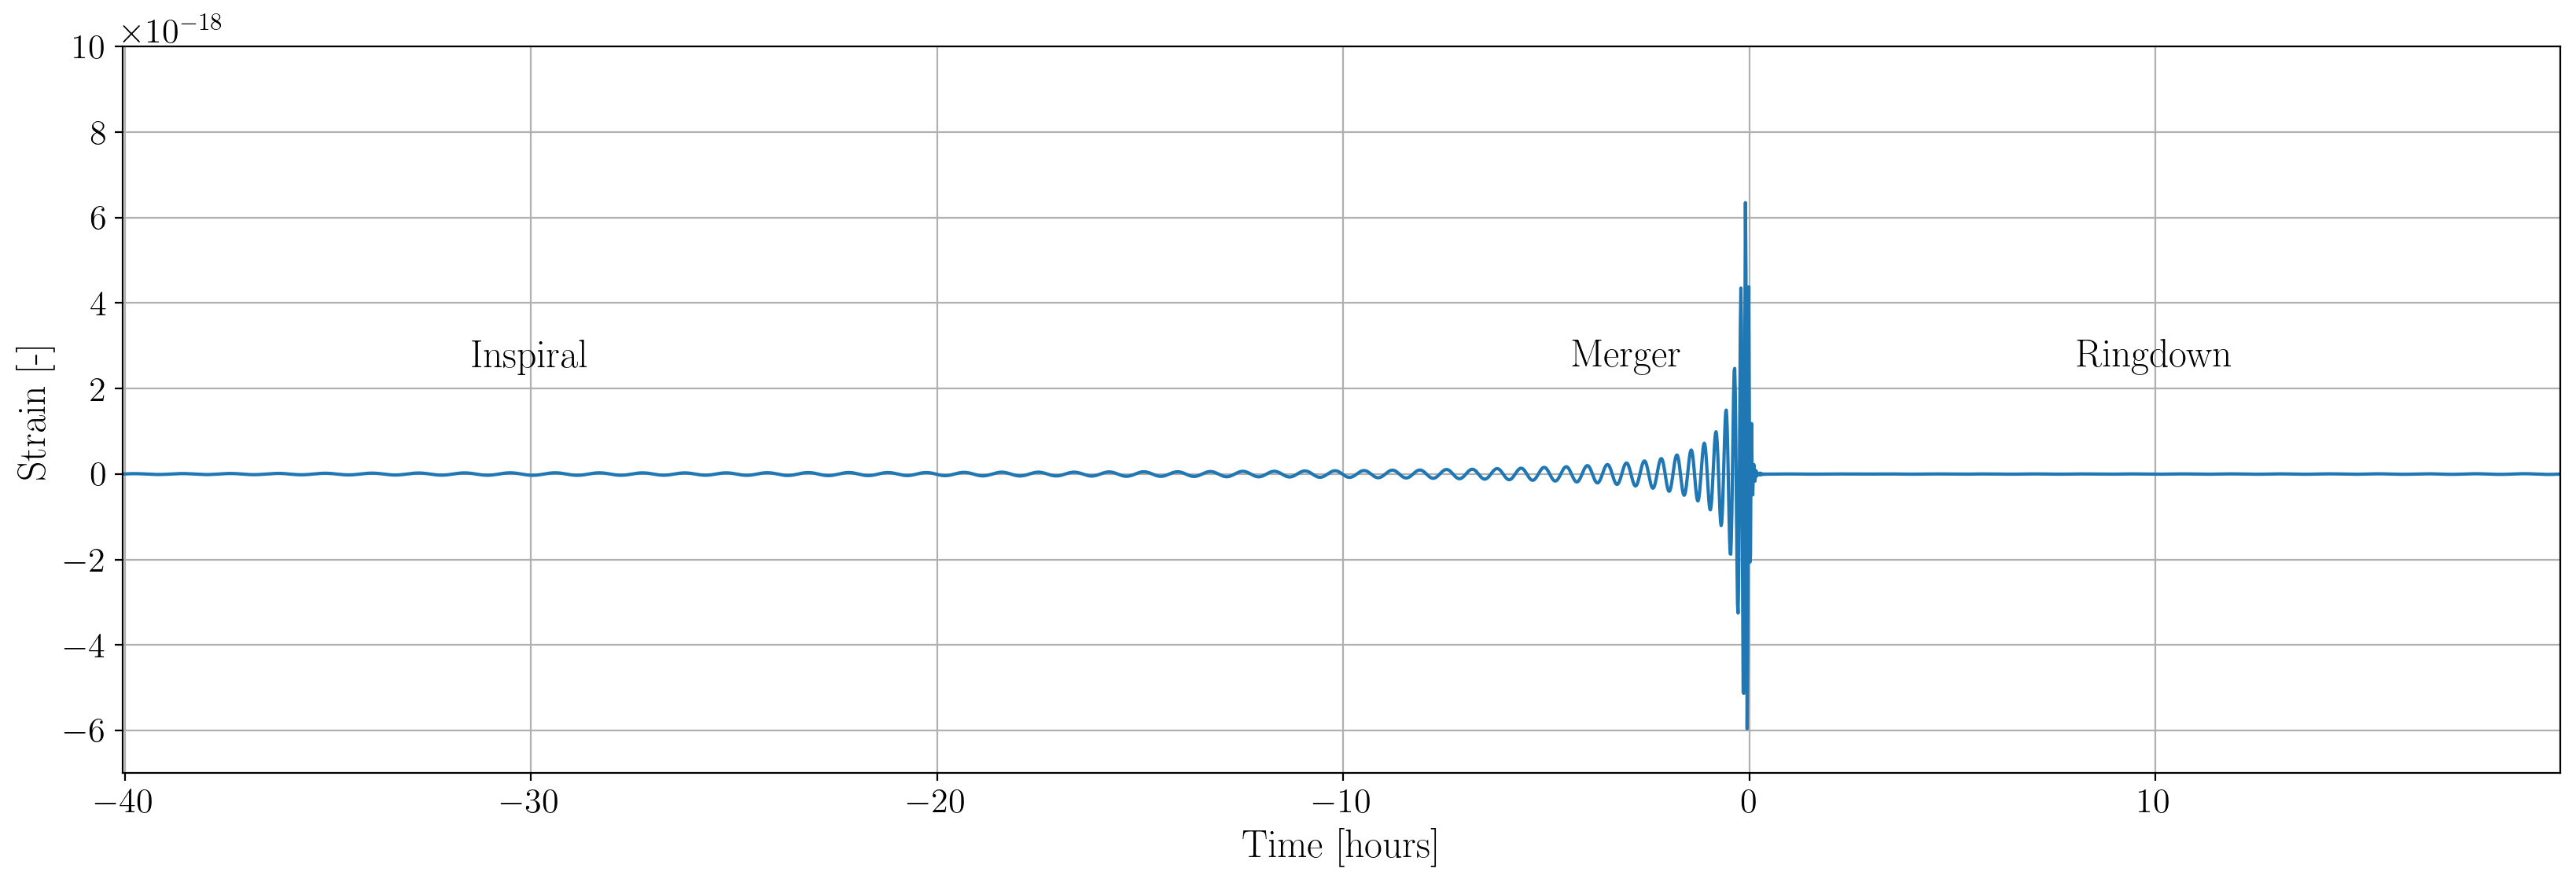

In [87]:
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), use_gpu=False)

Tobs =  YRSID_SI/(365*24)*6
dt = 5. 
N = int(int(Tobs / dt)/2)*2
freq = np.fft.rfftfreq(N,dt)
freq[0] = freq[1]

m1 = 2e5
m2 = 2e5
a1 = 0.753
a2 = 0.621
dist = 10 * PC_SI * 1e9
phi_ref = 0.0 #np.pi/2
f_ref = 0.0
inc = 0.224
lam = 60*(np.pi/180)
beta = 90*(np.pi/180)
psi = 0
t_ref = Tobs - (2*60*60)

parameters = np.array([m1, m2, a1, a2, dist, phi_ref, f_ref, inc, lam, beta, psi, t_ref])

modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

wave_freq_domain = wave_gen(*parameters, 
                            freqs=freq, modes=modes, 
                            direct=False, fill=True, squeeze=True, length=1024)[0]

wave_time_domain = np.fft.irfft(wave_freq_domain, axis=-1)

## Construct a time array for plotting that has t_ref/dt at zero seconds converted to hours
time = np.arange(len(wave_time_domain[0])) * dt
time = time - t_ref
time = time / 360  # Convert seconds to hours

plt.figure(figsize=(20, 6))
plt.plot(time, wave_time_domain[0])
plt.xlim(time[0], time[-1])
plt.ylim(-7e-18, 10e-18)
plt.ylabel("Strain [-]", fontsize=fontsize_plot)
plt.xlabel("Time [hours]", fontsize=fontsize_plot)

## Add a single dot at time = - 30, y = 0.6e-17 and add text below it saying "Inspiral"

plt.text(-30, 0.25e-17, "Inspiral", fontsize=fontsize_plot, ha='center')

plt.text(-3, 0.25e-17, "Merger", fontsize=fontsize_plot, ha='center')

plt.text(10, 0.25e-17, "Ringdown", fontsize=fontsize_plot, ha='center')

plt.grid(True)
plt.savefig('waveform_time_domain_labels.pdf', dpi=300)

In [68]:
time

array([-40.04214186, -40.02825297, -40.01436409, ...,  19.94396925,
        19.95785814,  19.97174703], shape=(4322,))

In [7]:
# Tobs is the obvesrvation time in seconds. YRSID_SI is a siderial year = 31558149.763545603 seconds
Tobs = YRSID_SI / 2.

# This is the sampling interval, i.e., the time between two samples. The sampling rate is 1/dt
dt = 5.  # sec

# N is the number of samples in your original time-domain signal.
N = int(int(Tobs / dt)/2)*2

# Convert Tobs into an integer number.
Tobs = N * dt

# This function returns the array of sample frequencies corresponding to the positive frequencies of the real-input Fast Fourier Transform (rFFT)
# The list goes from from zero to the Nyquist frequency, which is half the sampling rate: f[-1] = df/2 = 1/(2*dt)
# len(f) = floor(N/2) + 1 because the Nyquist frequency is included and the negative frequencies are not included in the rFFT
freq = np.fft.rfftfreq(N,dt)

# f[0] is 0.0. To avoid this, set f[0] to f[1]
freq[0] = freq[1]

# stochastic_params in sens_kwargs takes the time to add galactic foreground noise. It makes sense to put it as Tobs, which is the duration of observation.
# This is why N was calculated using Tobs and not written explicitly.
sens_kwargs = dict(stochastic_params=(Tobs,))

# Put the LISA sensitivity model in a list. See lisatools.sensitivity.get_stock_sensitivity_options for the list of available models.
# Does not work for FlatPSDFunction and it's slightly higher than the model for LISASens and CornishLISASens at low frequencies.
plot_labels = ['A', 'E', 'T']

# SensitivityMatrix class gives a model of the LISA instrumental noises, given a frequency array, for every TDI channel in sens_model_array
sens_mat = AET1SensitivityMatrix(freq)

noises = noise_generation.generate_noise(N, dt, sens_mat, seed = 42, verification_plot=False, time_domain_plot=False, plot_lables=plot_labels)
fout, pxxout = noise_generation.noise_time_to_freq_domain(noises, dt)


In [6]:
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), use_gpu=False)

m1 = 3e5
m2 = 1.5e5
a1 = 0.753
a2 = 0.621
dist = 10 * PC_SI * 1e9
phi_ref = 0.0 #np.pi/2
f_ref = 0.0
inc = 0.224
lam = 60*(np.pi/180)
beta = 90*(np.pi/180)
psi = 0
t_ref = Tobs - (2*60*60)
parameters = np.array([m1, m2, a1, a2, dist, phi_ref, f_ref, inc, lam, beta, psi, t_ref])
modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

wave_freq_domain = wave_gen(*parameters, 
                            freqs=freq, modes=modes, 
                            direct=False, fill=True, squeeze=True, length=1024)[0]

wave_time_domain = np.fft.irfft(wave_freq_domain, axis=-1)
wave_time_domain_with_noise = wave_time_domain + noises
fout_withnoise, pxxout_withnoise = noise_generation.noise_time_to_freq_domain(wave_time_domain_with_noise, dt)

/var/folders/zq/6x2qbk397t13zwgl047mwbkm0000gn/T/ipykernel_14309/3421472082.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


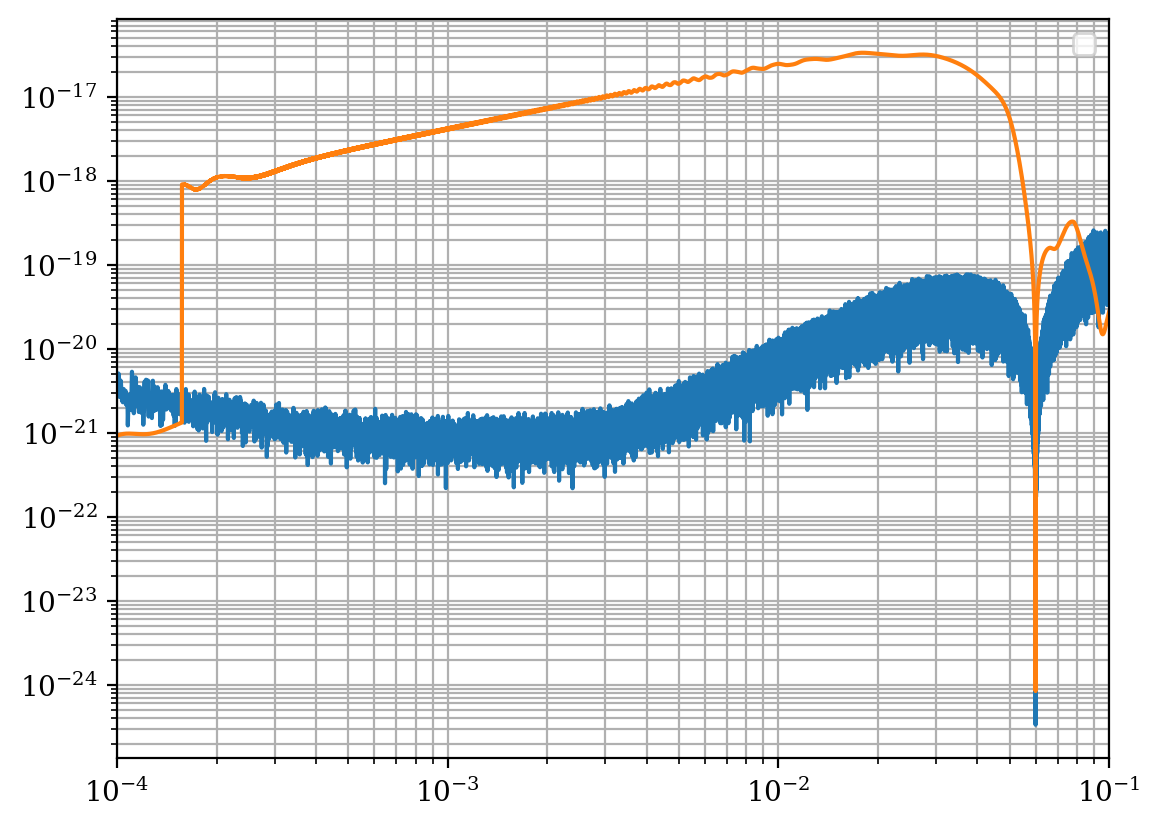

In [10]:
plt.loglog(fout[0], np.sqrt(pxxout[0]))
plt.loglog(freq, np.abs(wave_freq_domain[0]))
plt.xlim(1e-4, 0.1)
plt.legend()
plt.grid(True, which='both')

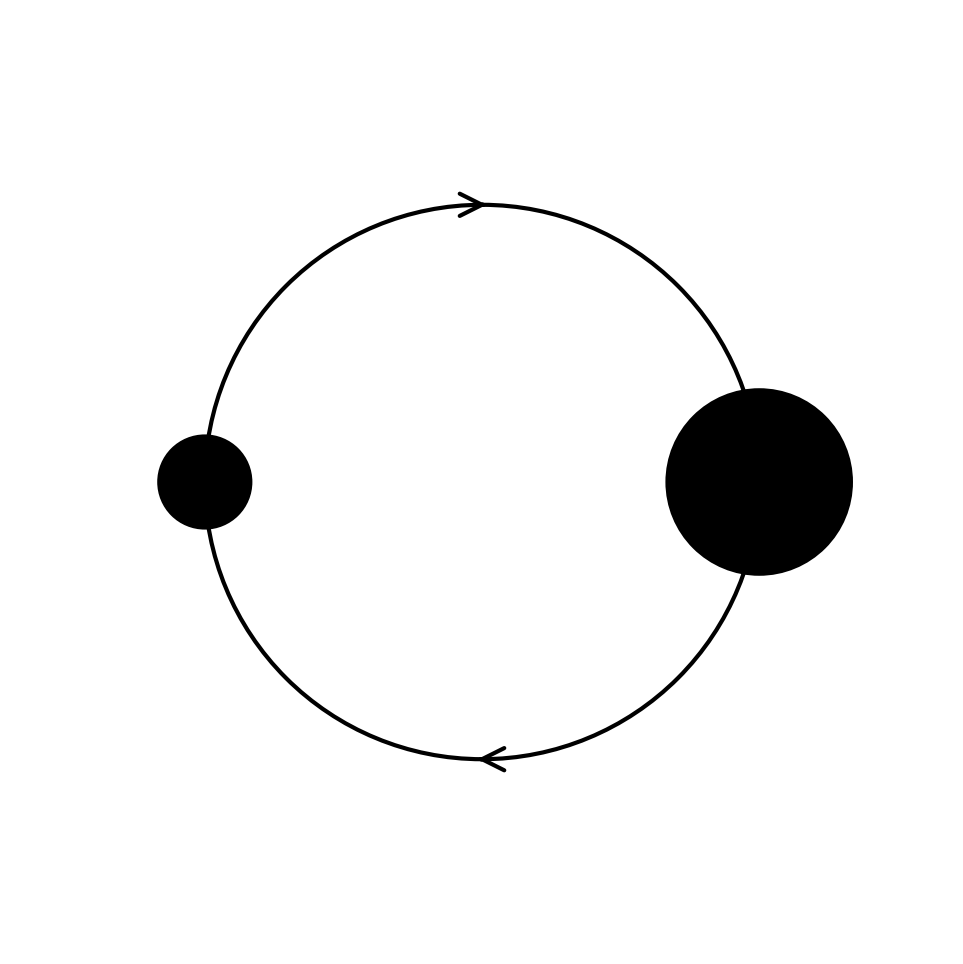

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle

fig, ax = plt.subplots(figsize=(6, 6))

binary_radius = 3
# --- Circle parameters ---
x1, r1 = -binary_radius, 0.5    # left circle
x2, r2 = binary_radius, 1    # right circle

circle1 = Circle((x1, 0), r1, color='black', fill=True)
circle2 = Circle((x2, 0), r2, color='black', fill=True)
ax.add_patch(circle1)
ax.add_patch(circle2)

# Set equal scaling to ensure the circle looks circular
ax.set_aspect('equal')

radius=binary_radius
angle1=90
angle2=270
# Draw the circle
circle = Circle((0, 0), radius, color='black', fill=False, linewidth=1.5)
ax.add_artist(circle)

# Function to convert polar to Cartesian coordinates
def polar_to_cartesian(r, angle):
    x = r * np.cos(np.radians(angle))
    y = r * np.sin(np.radians(angle))
    return x, y

# Function to create an arrow pointing clockwise
def create_arrow(angle):
    x, y = polar_to_cartesian(radius, angle)
    dx = 0.05 * np.cos(np.radians(angle - 90))  # Arrowhead direction
    dy = 0.05 * np.sin(np.radians(angle - 90))  # Arrowhead direction
    return FancyArrowPatch((x, y), (x + dx, y + dy), mutation_scale=20, color="black", arrowstyle="->", linewidth=1.5)

# Draw first arrow at angle1
arrow1 = create_arrow(angle1)
ax.add_patch(arrow1)

# Draw second arrow at angle2
arrow2 = create_arrow(angle2)
ax.add_patch(arrow2)

# Set the axis limits
ax.set_xlim(-radius - 2, radius + 2)
ax.set_ylim(-radius - 2, radius + 2)

# Hide the axis
ax.axis('off')

# Show the plot
plt.show()



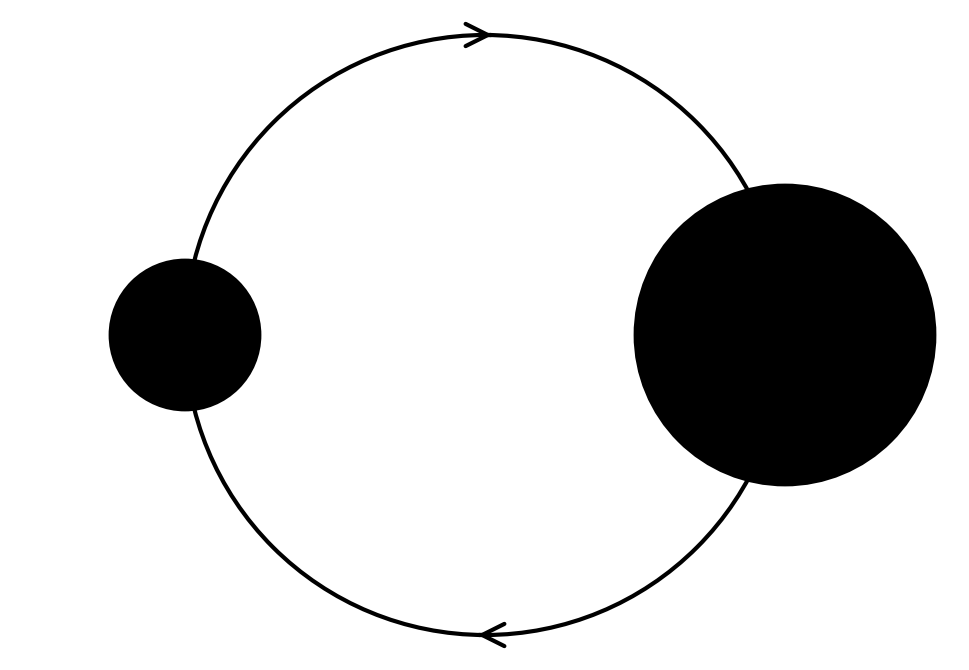

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle

fig, ax = plt.subplots(figsize=(6, 6))

binary_radius = 2
# --- Circle parameters ---
x1, r1 = -binary_radius, 0.5    # left circle
x2, r2 = binary_radius, 1    # right circle

circle1 = Circle((x1, 0), r1, color='black', fill=True)
circle2 = Circle((x2, 0), r2, color='black', fill=True)
ax.add_patch(circle1)
ax.add_patch(circle2)

# Set equal scaling to ensure the circle looks circular
ax.set_aspect('equal')

radius=binary_radius
angle1=90
angle2=270
# Draw the circle
circle = Circle((0, 0), radius, color='black', fill=False, linewidth=1.5)
ax.add_artist(circle)

# Function to convert polar to Cartesian coordinates
def polar_to_cartesian(r, angle):
    x = r * np.cos(np.radians(angle))
    y = r * np.sin(np.radians(angle))
    return x, y

# Function to create an arrow pointing clockwise
def create_arrow(angle):
    x, y = polar_to_cartesian(radius, angle)
    dx = 0.05 * np.cos(np.radians(angle - 90))  # Arrowhead direction
    dy = 0.05 * np.sin(np.radians(angle - 90))  # Arrowhead direction
    return FancyArrowPatch((x, y), (x + dx, y + dy), mutation_scale=20, color="black", arrowstyle="->", linewidth=1.5)

# Draw first arrow at angle1
arrow1 = create_arrow(angle1)
ax.add_patch(arrow1)

# Draw second arrow at angle2
arrow2 = create_arrow(angle2)
ax.add_patch(arrow2)

ax_limit_xaxis = 3.1
ax_limit_yaxis = 2.1
# Set the axis limits
ax.set_xlim(-ax_limit_xaxis, ax_limit_xaxis)
ax.set_ylim(-ax_limit_yaxis, ax_limit_yaxis)

# Hide the axis
ax.axis('off')
plt.savefig('inspiral.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()



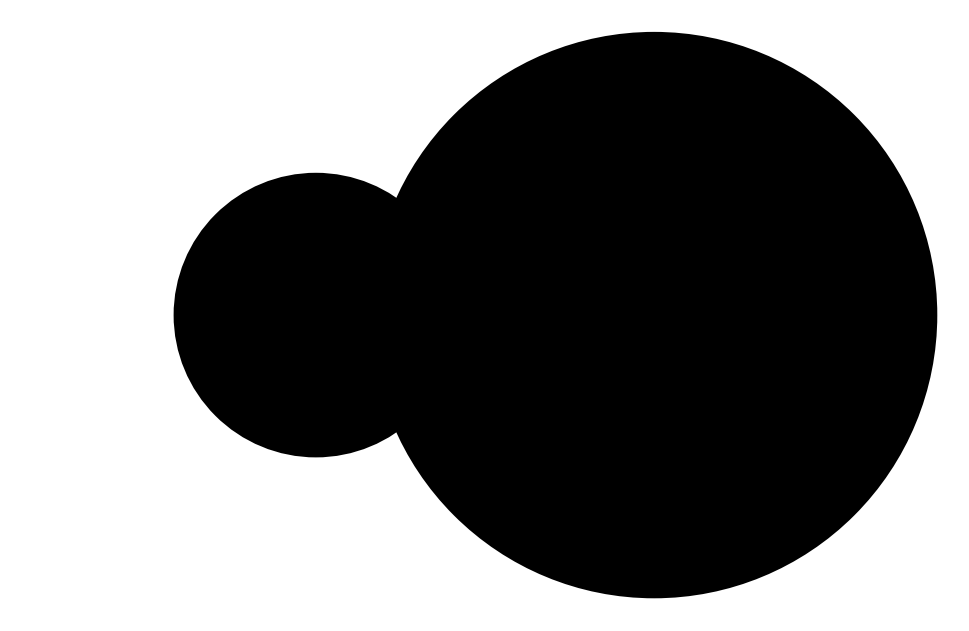

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle

fig, ax = plt.subplots(figsize=(6, 6))

binary_radius = 0.6
# --- Circle parameters ---
x1, r1 = -binary_radius, 0.5    # left circle
x2, r2 = binary_radius, 1    # right circle

circle1 = Circle((x1, 0), r1, color='black', fill=True)
circle2 = Circle((x2, 0), r2, color='black', fill=True)
ax.add_patch(circle1)
ax.add_patch(circle2)

# Set equal scaling to ensure the circle looks circular
ax.set_aspect('equal')

ax_limit_xaxis = 1.65
ax_limit_yaxis = 1.05
# Set the axis limits
ax.set_xlim(-ax_limit_xaxis, ax_limit_xaxis)
ax.set_ylim(-ax_limit_yaxis, ax_limit_yaxis)

# Hide the axis
ax.axis('off')

plt.savefig('merger.png', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()



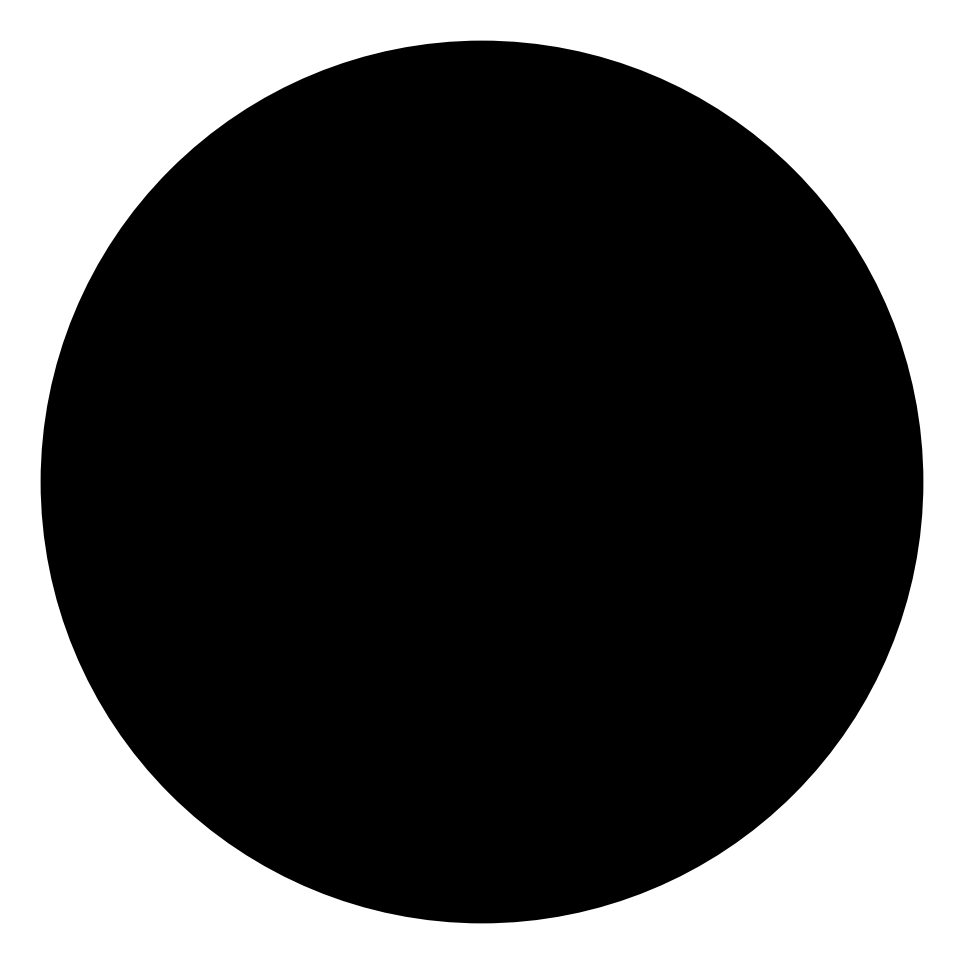

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle

fig, ax = plt.subplots(figsize=(6, 6))

# --- Circle parameters ---
x1, r1 = 0, 2 # left circle

circle1 = Circle((x1, 0), r1, color='black', fill=True)

ax.add_patch(circle1)


# Set equal scaling to ensure the circle looks circular
ax.set_aspect('equal')

ax_limit = 2.1
# Set the axis limits
ax.set_xlim(-ax_limit, ax_limit)
ax.set_ylim(-ax_limit, ax_limit)

# Hide the axis
ax.axis('off')

plt.savefig
# Show the plot
plt.show()



In [60]:
(0.5**3 + 1**3)**(1/3)

1.040041911525952